# Import and data extraction

In [1]:
import h5py
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import galpy
from galpy.potential import evaluateDensities
from galpy.orbit import Orbit
from astropy import units  as u
from astropy import constants as c

In [2]:
data = h5py.File('cutout_17.hdf5', 'r')
data.keys()
h = data['Header'].attrs['HubbleParam']

#All attributes
for x in list(data['Header'].attrs):
    print(f'The value for {x} is: {data['Header'].attrs[x]}')


The value for BoxSize is: 35000.0
The value for CutoutID is: 17
The value for CutoutRequest is: PartType0=CenterOfMass,Coordinates,Density,ElectronAbundance,EnergyDissipation,GFM_AGNRadiation,GFM_CoolingRate,GFM_Metallicity,GFM_Metals,GFM_MetalsTagged,GFM_WindDMVelDisp,GFM_WindHostHaloMass,InternalEnergy,Machnumber,MagneticField,MagneticFieldDivergence,Masses,NeutralHydrogenAbundance,ParticleIDs,Potential,StarFormationRate,SubfindDMDensity,SubfindDensity,SubfindHsml,SubfindVelDisp,Velocities+PartType1=Coordinates,ParticleIDs,Potential,SubfindDMDensity,SubfindDensity,SubfindHsml,SubfindVelDisp,Velocities+PartType3=FluidQuantities,ParentID,TracerID+PartType4=BirthPos,BirthVel,Coordinates,GFM_InitialMass,GFM_Metallicity,GFM_Metals,GFM_MetalsTagged,GFM_StellarFormationTime,GFM_StellarPhotometrics,Masses,ParticleIDs,Potential,StellarHsml,SubfindDMDensity,SubfindDensity,SubfindHsml,SubfindVelDisp,Velocities+PartType5=BH_BPressure,BH_CumEgyInjection_QM,BH_CumEgyInjection_RM,BH_CumMassGrowth_Q

In [3]:
#Look at data contained in parttype1
print(data['PartType1'].keys())
print(data['PartType1']["ParticleIDs"])
print(list(data['PartType1']["ParticleIDs"].attrs))


<KeysViewHDF5 ['Coordinates', 'ParticleIDs', 'Potential', 'SubfindDMDensity', 'SubfindDensity', 'SubfindHsml', 'SubfindVelDisp', 'Velocities']>
<HDF5 dataset "ParticleIDs": shape (278904,), type "<u8">
['a_scaling', 'h_scaling', 'length_scaling', 'mass_scaling', 'to_cgs', 'velocity_scaling']


In [4]:
#Extract data
size = data['Header'].attrs['BoxSize']/data['Header'].attrs['HubbleParam'] #units.kpc
center = np.array([size/2, size/2, size/2])
a = data['Header'].attrs['Time'] #scale factor
z = data['Header'].attrs['Redshift'] 
m_dm = data["Header"].attrs["MassTable"][1] * 1e10 / h #units.Msun
N = data["Header"].attrs["NumPart_ThisFile"][1]
coordinates = data['PartType1']["Coordinates"][:]/data['Header'].attrs['HubbleParam'] #units.kpc ->Convert from comoving
velocities = data['PartType1']["Velocities"][:]*np.sqrt(a) #units.km /units.s 
# Gravitational constant (arbitrary units)
G = 4.302e-6  # (kpc * (km/s)^2) / Msun

# Compute potential from data


In [5]:
import numpy as np
from numba import njit, prange

# 1. Build tree -> nodes stored in NumPy arrays to speed up
def build_tree(positions, m_particle, BoxSize):
    """
    Build a tree structure.
    Each node stores:
      - center: cube center in 3D
      - size: cube side length
      - mass: total mass inside this cube
      - com: center of mass of all particles in this cube
      - children: indices of its 8 subcubes (-1 if empty)
    """

    N = len(positions)
    max_nodes = 8 * N  # upper bound -> if all particles are subdivided in single cells
    
    # Arrays for all node properties
    centers = np.zeros((max_nodes, 3))           # node center coordinates
    sizes = np.zeros(max_nodes)                  # cube size
    node_masses = np.zeros(max_nodes)            # total mass in node
    coms = np.zeros((max_nodes, 3))              # node center of mass
    children = -np.ones((max_nodes, 8), dtype=np.int64)  # child indices (-1 = no child)
    
    # Create root node 
    centers[0] = np.array([BoxSize / 2] * 3)
    sizes[0] = BoxSize
    node_count = 1  # how many nodes we have created
    
    # Stack indicates which node we are building (0= root), how many particles are in that node (now all)
    stack = [(0, np.arange(N))]
    
    while stack:
        #Extract the node index and amount of particles
        node_idx, p_idx = stack.pop() 
        if len(p_idx) == 0: #sanity check that this is not 0
            continue
        
        # Compute total mass and center of mass of this node
        node_masses[node_idx] = len(p_idx) * m_particle
        coms[node_idx] = np.mean(positions[p_idx], axis=0)
        
        # If node contains only one particle → it's a leaf
        if len(p_idx) == 1:
            continue
        
        # Otherwise subdivide the node into 8 subcubes
        child_size = sizes[node_idx] / 2
        half = child_size / 2  # offset from parent center to child center
        
        # Create the 8 children around the node center -> negative and positive wrt to parent center
        offsets = np.array([[dx, dy, dz] for dx in [-1, 1]
                                         for dy in [-1, 1]
                                         for dz in [-1, 1]]) * half
        
        for c in range(8):
            #Create new node & store center and sizes in the array
            child_center = centers[node_idx] + offsets[c]
            centers[node_count] = child_center
            sizes[node_count] = child_size
            
            # Determine which particles belong to this child cube
            cmin = child_center - child_size / 2 #minimum dimensions of the box
            cmax = child_center + child_size / 2 #maximum dimensions of the box
            mask = np.all((positions[p_idx] >= cmin) & (positions[p_idx] < cmax), axis=1) #particle in the box?
            child_particles = p_idx[mask] #particle indexes that are inside the box
            
            # If the child contains particles, link it and add to stack
            if len(child_particles) > 0:
                children[node_idx, c] = node_count
                stack.append((node_count, child_particles))
            
            node_count += 1
    
    # Return all arrays truncated to the actual number of nodes instead of max
    return centers[:node_count], sizes[:node_count], node_masses[:node_count], coms[:node_count], children[:node_count]


# 2. Compute potentials using Barnes-Hut algorithm
@njit(parallel=True) #makes process faster by looping over multiple cores
def compute_potential(positions, m_particle,
                                centers, sizes, node_masses, coms, children,
                                G, theta, BoxSize, eps):
    """
    Compute the gravitational potential for all particles using
    the Barnes–Hut approximation and the pre-built tree.

    Parameters
    ----------
    positions : (N,3) array of particle coordinates
    m_particle: mass of particle (all equal)
    centers, sizes, node_masses, coms, children: tree structure
    G : gravitational constant [kpc (km/s)^2 / Msun]
    theta : opening angle 
    BoxSize : box size 
    eps : softening length
    """

    N = len(positions)
    potentials = np.zeros(N)

    # Loop over all particles in parallel
    for i in prange(N):
        pos = positions[i]
        Phi_total = 0.0

        # Start with the root node (index 0)
        stack = [0]

        while len(stack) > 0:

            #Look at a node from the stack
            node_idx = stack.pop()

            # Skip empty nodes
            if node_masses[node_idx] == 0:
                continue

            # Compute distance vector from particle to node COM
            r = coms[node_idx] - pos

            # Apply periodic boundary conditions (minimum image convention)
            #r = r - BoxSize * np.round(r / BoxSize)

            dist = np.sqrt((r * r).sum()) + eps

            # Skip self-interaction (same particle)
            if dist < eps:
                continue

            # Barnes–Hut criterion:
            # if node is sufficiently far (size/dist < theta) or its a leaf (children == -1)
            # approximate it as a single mass at its COM
            if (sizes[node_idx] / dist) < theta or np.all(children[node_idx] == -1):
                Phi_total += -G * node_masses[node_idx] / dist
            else:
                # Otherwise, open the node and evaluate its children
                for c in children[node_idx]:
                    if c != -1:
                        stack.append(c)

        potentials[i] = Phi_total

    return potentials

In [6]:
theta = 0.5 #common value
eps = 1e-3

#build tree
centers, sizes, node_masses, coms, children = build_tree(coordinates, m_dm, size)

print(f"Tree built: {len(node_masses)} nodes")

# 3. Compute potentials
potentials = compute_potential(
    coordinates,
    m_dm,
    centers,
    sizes,
    node_masses,
    coms,
    children,
    G,
    theta,
    size,
    eps
)


# 4. Output
print("Potentials shape:", potentials.shape)
print("Example potential:", potentials[0])


Tree built: 1085329 nodes
Potentials shape: (278904,)
Example potential: -50401.84125079335


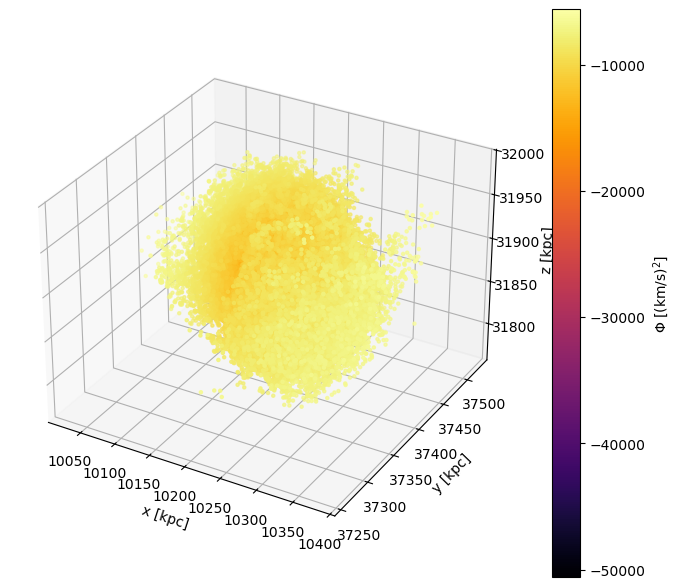

In [7]:
#Plot 3D distribution
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    coordinates[:,0], coordinates[:,1], coordinates[:,2],
    c=potentials, cmap='inferno', s=5
)
plt.colorbar(sc, label=r'$\Phi$ [(km/s)$^2$]')
ax.set_xlabel("x [kpc]")
ax.set_ylabel("y [kpc]")
ax.set_zlabel("z [kpc]")
plt.tight_layout()
plt.savefig('Images/Potential3D.png')
plt.show()

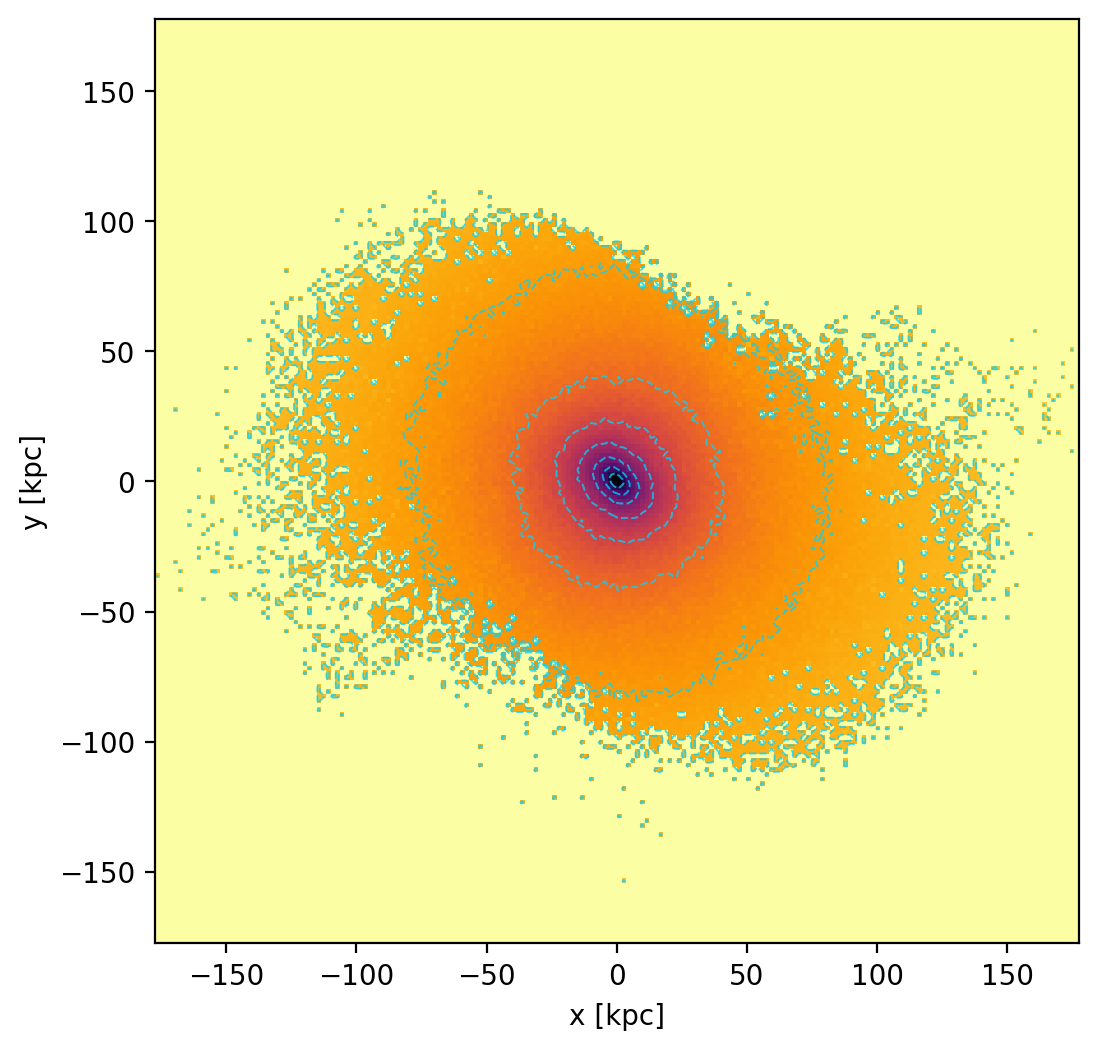

In [8]:
#Most bound particle
i = np.argmin(potentials)
pot = np.min(potentials)
most_bound = coordinates[i]

#shift coordinate system and fix center to middle of the plot
x = coordinates[:,0] - most_bound[0]
y = coordinates[:,1] - most_bound[1]
z = coordinates[:,2] - most_bound[2]

rmax = max(
    np.abs(x).max(),
    np.abs(y).max(),
    np.abs(z).max()
)

xmin, xmax = -rmax, rmax
ymin, ymax = -rmax, rmax
zmin, zmax = -rmax, rmax

#Plot 2D hist
bins = 200
H, xedges, yedges = np.histogram2d(x, y,
                                   bins=bins, range = ((xmin, xmax), (ymin, ymax)), weights=potentials)
counts, _, _ = np.histogram2d(x,y, range=((xmin, xmax), (ymin, ymax)),
                              bins=bins)
phi_map = H / np.maximum(counts, 1)  # avoid divide by zero

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)  
im = ax.imshow(phi_map.T, origin='lower',
           extent=(xmin, xmax, ymin, ymax),
           aspect='equal',
           cmap='inferno')

# Compute contour levels
levels = np.linspace(phi_map.min(), phi_map.max(), 10)

# Build coordinate grid for contours
Xc, Yc = np.meshgrid(
    0.5 * (xedges[:-1] + xedges[1:]),
    0.5 * (yedges[:-1] + yedges[1:])
)

# Draw contours
ax.contour(
    Xc,
    Yc,
    phi_map.T,
    levels=levels,
    linewidths=0.7,
    colors='#00d4ff',
    alpha=0.75
)

ax.set_xlabel("x [kpc]")
ax.set_ylabel("y [kpc]")
plt.savefig('Images/Projectedpotxy.png', dpi=300)
plt.show()


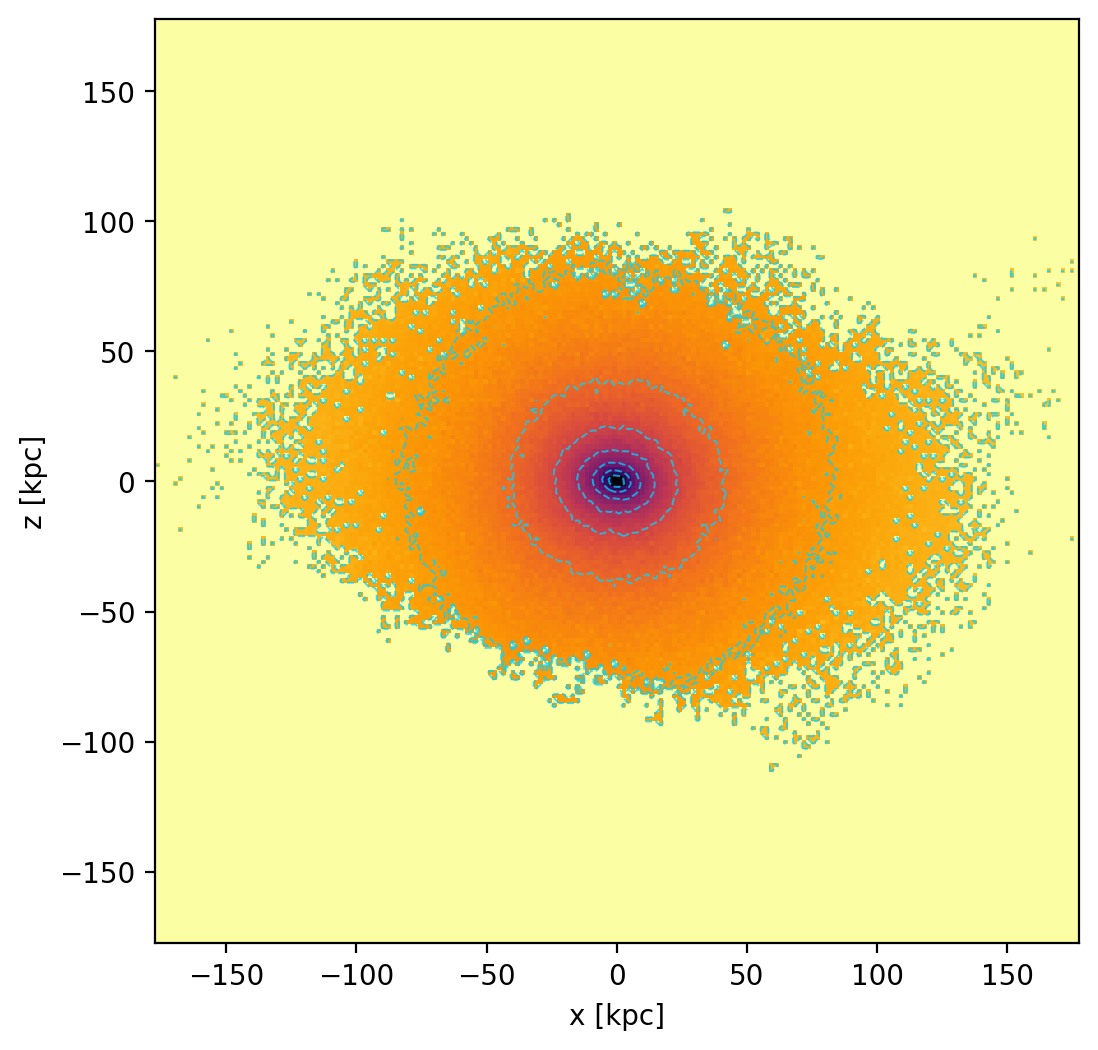

In [9]:
#Plot 2D hist
bins = 200
H, xedges, zedges = np.histogram2d(x, z,
                                   bins=bins, range = ((xmin, xmax), (zmin, zmax)), weights=potentials)
counts, _, _ = np.histogram2d(x,z, range=((xmin, xmax), (zmin, zmax)),
                              bins=bins)
phi_map = H / np.maximum(counts, 1)  # avoid divide by zero

fig, ax = plt.subplots(figsize=(6, 6), dpi=200)  
im = ax.imshow(phi_map.T, origin='lower',
           extent=(xmin, xmax, zmin, zmax),
           aspect='equal',
           cmap='inferno')

# Compute contour levels
levels = np.linspace(phi_map.min(), phi_map.max(), 10)

# Build coordinate grid for contours
Xc, Zc = np.meshgrid(
    0.5 * (xedges[:-1] + xedges[1:]),
    0.5 * (zedges[:-1] + zedges[1:])
)

# Draw contours
ax.contour(
    Xc,
    Zc,
    phi_map.T,
    levels=levels,
    linewidths=0.7,
    colors='#00d4ff',
    alpha=0.75
)

ax.set_xlabel("x [kpc]")
ax.set_ylabel("z [kpc]")
plt.savefig('Images/Projectedpotxz.png', dpi=300)
plt.show()

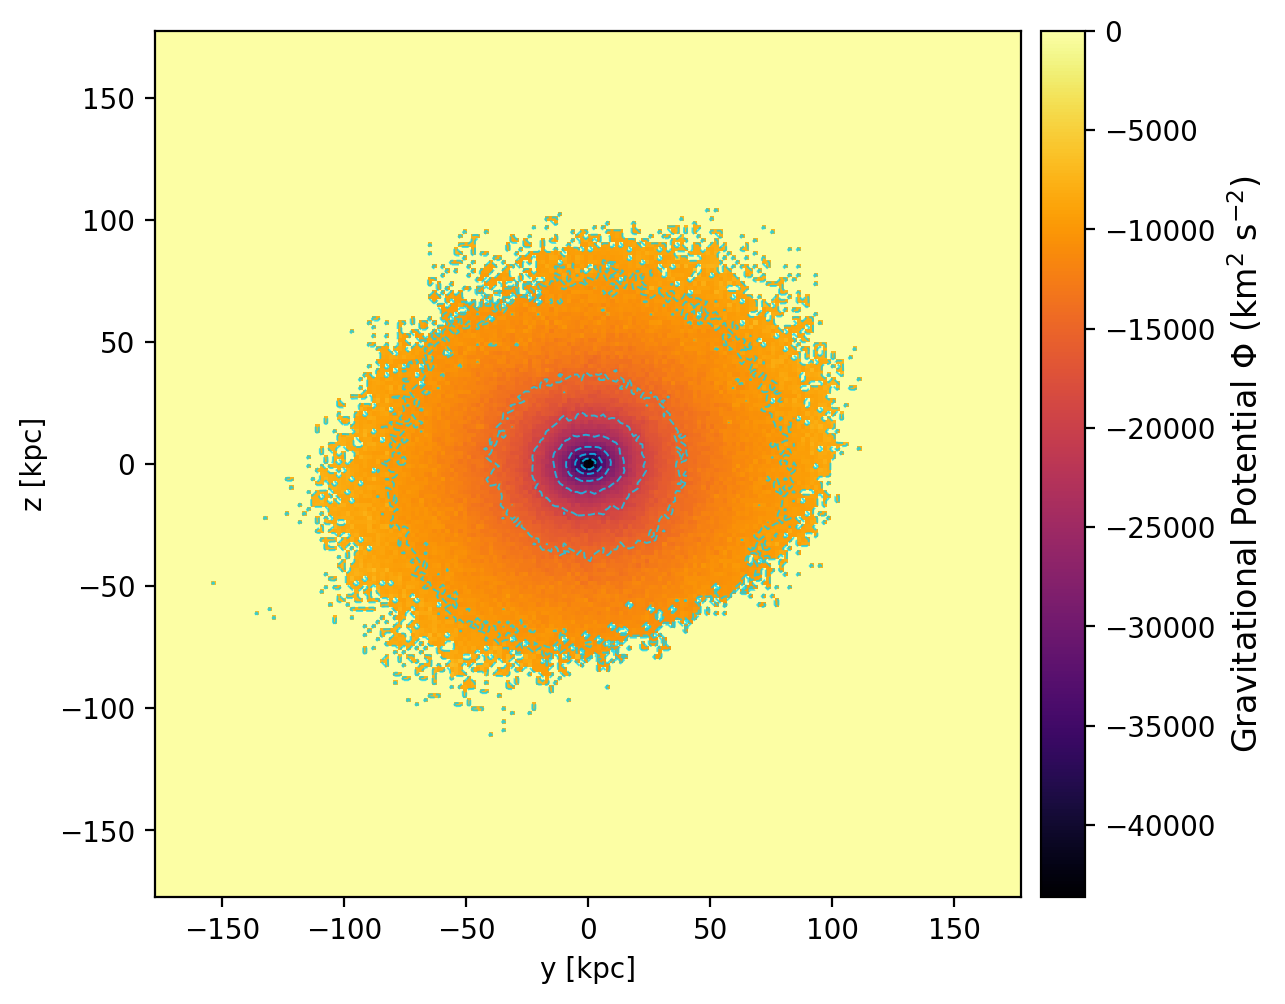

In [10]:
#Plot 2D hist
bins = 200
H, yedges, zedges = np.histogram2d(y, z,
                                   bins=bins, range = ((ymin, ymax), (zmin, zmax)), weights=potentials)
counts, _, _ = np.histogram2d(y,z, range=((ymin, ymax), (zmin, zmax)),
                              bins=bins)
phi_map = H / np.maximum(counts, 1)  # avoid divide by zero

fig = plt.figure(figsize=(6, 6), dpi=200)
ax = fig.add_subplot(111)

im = ax.imshow(phi_map.T,
               origin='lower',
               extent=(ymin, ymax, zmin, zmax),
               aspect='equal',
               cmap='inferno')

# Compute contour levels
levels = np.linspace(phi_map.min(), phi_map.max(), 10)

# Build coordinate grid for contours
Yc, Zc = np.meshgrid(
    0.5 * (yedges[:-1] + yedges[1:]),
    0.5 * (zedges[:-1] + zedges[1:])
)

# Draw contours
ax.contour(
    Yc,
    Zc,
    phi_map.T,
    levels=levels,
    linewidths=0.7,
    colors='#00d4ff',
    alpha=0.75
)

from mpl_toolkits.axes_grid1 import make_axes_locatable
# --- PERFECTLY MATCHED COLORBAR ---
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)  # no shrink needed
cbar.set_label(r"Gravitational Potential $\Phi$ (km$^2$ s$^{-2}$)", fontsize=12)
cbar.ax.tick_params(labelsize=10)


ax.set_xlabel("y [kpc]")
ax.set_ylabel("z [kpc]")
plt.savefig('Images/Projectedpotyz.png', bbox_inches="tight", dpi=300)
plt.show()

# Part 2) Compute density profile $\rho(r)$ from particle data

## a) Compute and plot the spherical density function

In [11]:
center_of_mass = np.mean(coordinates, axis=0) #Naieve, does not give the most bound particle
print(center_of_mass)

#Most bound particle
i = np.argmin(potentials)
pot = np.min(potentials)
most_bound = coordinates[i]
print(most_bound)


[10206.77606909 37411.1265164  31882.36022063]
[10205.99425338 37411.93283495 31882.18198569]


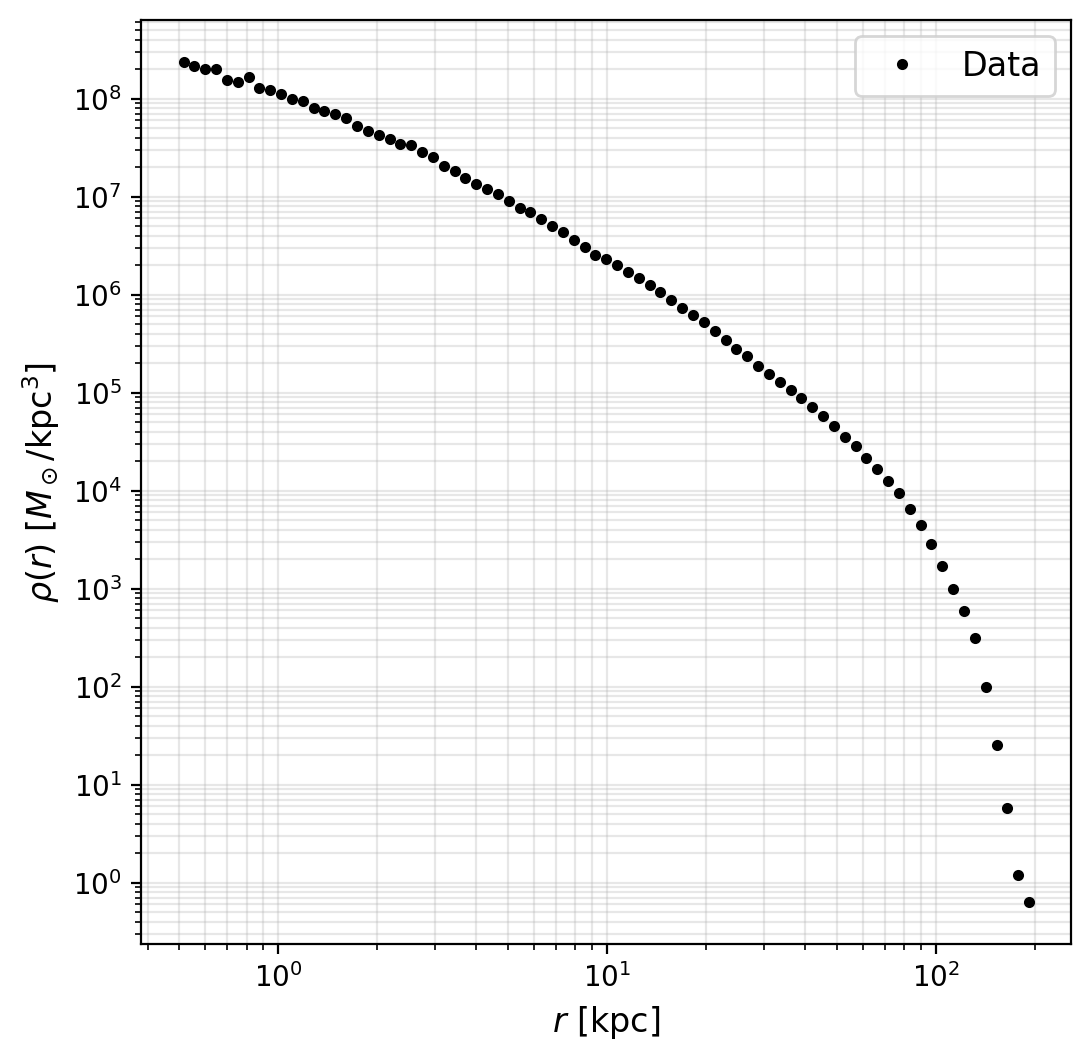

In [12]:
center_of_mass = np.mean(coordinates, axis=0)
radius_particles = np.linalg.norm(coordinates - most_bound, axis=1) #compute the radius of each particle (distance to most bound particle)


# Log-spaced bins
N_bins = 80
r_min = np.percentile(radius_particles, 0.1)     # avoid r=0 bin
r_max = np.max(radius_particles)
r_bins = np.logspace(np.log10(r_min), np.log10(r_max), N_bins)

particles_per_bin, _ = np.histogram(radius_particles, bins = r_bins) #array with the radius of each particle in N_bins bins
shell_volume = (4/3)*np.pi*(r_bins[1:]**3 - r_bins[:-1]**3) #volume of shell (r_i+1 - r_i)
rho_data = particles_per_bin*m_dm/shell_volume
r_mid = np.sqrt(r_bins[1:] * r_bins[:-1])

# Poisson uncertainty
sigma_rho = m_dm * np.sqrt(np.maximum(particles_per_bin, 1)) / shell_volume
sigma_log10 = (1/np.log(10)) * sigma_rho / np.maximum(rho_data, 1e-300)

import matplotlib.pyplot as plt
plt.figure(figsize= (6,6), dpi = 200)
plt.loglog(r_mid, rho_data, "k.", label="Data")
plt.xlabel(r"$r$ [kpc]", fontsize=12)
plt.ylabel(r"$\rho(r)$ [$M_\odot$/kpc$^3$]", fontsize=12)
plt.grid(which = 'both', alpha = 0.3)
plt.legend(fontsize=12)
plt.tick_params(which="both", labelsize=10)
plt.savefig('Images/densitydata.png', dpi=300)
plt.show()

## b) Fit the density with a function that can be used in galpy

A list with the spherical potentials in Galpy can be found __[here](https://docs.galpy.org/en/latest/reference/potential.html)__. We will try to fit the Plummer potential first.

23.309658196629506
Plummer best-fit params: [19.2652994] chi2=1647.12
Hernquist best-fit params: [15.73543932] chi2=476.88
C:\Users\grego\AppData\Local\Temp\ipykernel_17008\2900605605.py:59: RuntimeWarning: invalid value encountered in log10
  return np.log10(func(r, *p))

NFW best-fit params: [3.96223131e+07 5.13492391e+00] chi2=475.26


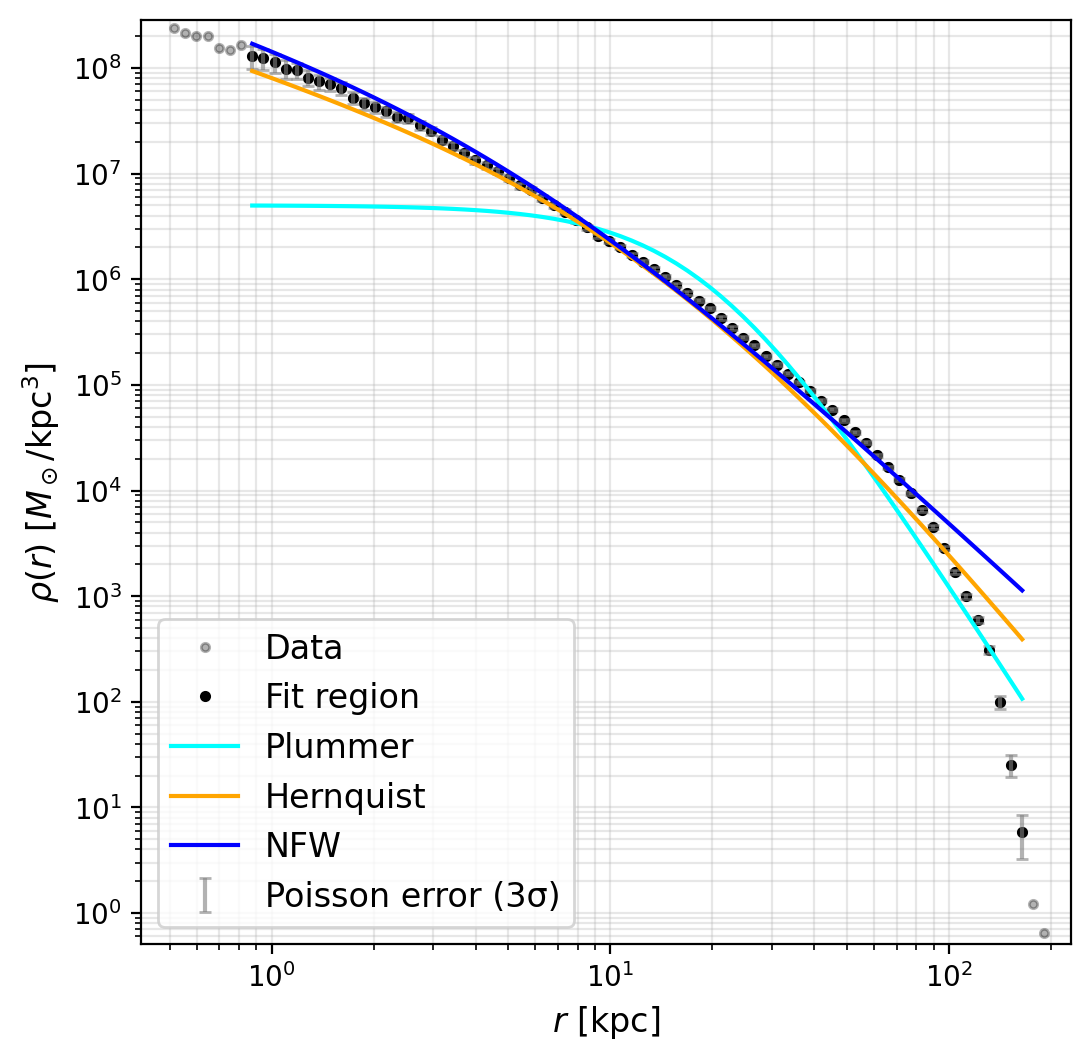

In [13]:
from scipy.optimize import curve_fit
from galpy.potential import PlummerPotential

M = m_dm*N
softening_length = 0.288 #scale below which gravity is smoothed to avoid divergences.
                         #is reported on TNG-50 for z <= 1

#Define the densities we want to fit
def rho_plummer(r, a):
    """Plummer density: M = total mass, a = scale"""
    return (3.0 * M) / (4.0 * np.pi * a**3) * (1.0 + (r**2 / a**2))**(-2.5)

def rho_hernquist(r, a):
    """Hernquist density"""
    return (M / (2.0 * np.pi)) * (a / (r * (r + a)**3))

def rho_nfw(r, rho_0, rs):
    """NFW parametrized by rho0 and scale radius rs_scale"""
    x = r/rs
    return rho_0 / (x * (1 + x)**2)


#guess for Plummer because fit is not good
order = np.argsort(radius_particles)
r_sorted = radius_particles[order]
cum_mass = np.arange(1, len(r_sorted)+1) * m_dm
Mtot = cum_mass[-1]
# find index where cum_mass >= 0.5*M
idx_half = np.searchsorted(cum_mass, 0.5 * Mtot)
r_half = r_sorted[idx_half] if idx_half < len(r_sorted) else r_sorted[-1]

# Plummer relation between a and r_half:
# a = r_half * sqrt(2^(2/3) - 1)
a_plummer_guess = r_half * np.sqrt(2.0**(2.0/3.0) - 1.0)
print(a_plummer_guess)


models = [
    ("Plummer", rho_plummer, [a_plummer_guess], "cyan"),
    ("Hernquist", rho_hernquist, [1.0], 'orange'),
    ("NFW", rho_nfw, [1e7, 1.0], 'blue'),
]

# Fit interval:  strip zeros / remove outer 10%/soften core
mask = (rho_data > 0) & (r_mid < 0.9 * r_mid.max()) & (r_mid > 3*softening_length)
rfit = r_mid[mask]
rhfit = rho_data[mask]
sigma_fit = sigma_log10[mask]

plt.figure(figsize=(6,6), dpi = 200)
plt.loglog(r_mid, rho_data, "k.", label="Data", alpha = 0.3)
plt.loglog(rfit, rhfit, "k. ", label = 'Fit region') #higlight fitted region
plt.errorbar(r_mid[mask], rho_data[mask], yerr=sigma_rho[mask]*3, fmt='none',
             ecolor='gray', alpha=0.6, capsize=2, label='Poisson error (3σ)')

for name, func, p0, color in models:
    # Fit in log‐space -> log10(rho), and compare to log10(rho_data)
    def fitfunc(r, *p):
        return np.log10(func(r, *p))
    
    popt, _ = curve_fit(fitfunc, rfit, np.log10(rhfit), sigma = sigma_fit, p0=p0, maxfev=20000)
    
    # Plot fitted curve
    plt.loglog(rfit, func(rfit, *popt), label=f"{name}", color = color)

    #Calculate reduced chi2 in logspace
    y_model  = np.log10(func(rfit, *popt))
    residual = np.log10(rhfit) - y_model
    chi2 = np.sum((residual/sigma_fit)**2)
    dof = len(rfit) - len(popt)
    reducedchi2 = chi2 / max(dof, 1)
    

    print(f"{name} best-fit params: {popt}", f"chi2={reducedchi2:.2f}")


plt.xlim(min(r_mid)*0.8, max(r_mid)*1.2)
plt.ylim(min(rho_data)*0.8, max(rho_data)*1.2)

plt.xlabel(r"$r$ [kpc]", fontsize=12)
plt.ylabel(r"$\rho(r)$ [$M_\odot / \mathrm{kpc}^3$]", fontsize=12)
plt.legend(fontsize=12)
plt.grid(which= 'both', alpha=0.3)
plt.tick_params(which="both", labelsize=10)
plt.savefig('Images/densityfit.png', dpi=300)
plt.show()

# Part 3) Use the best fit do do an analysis

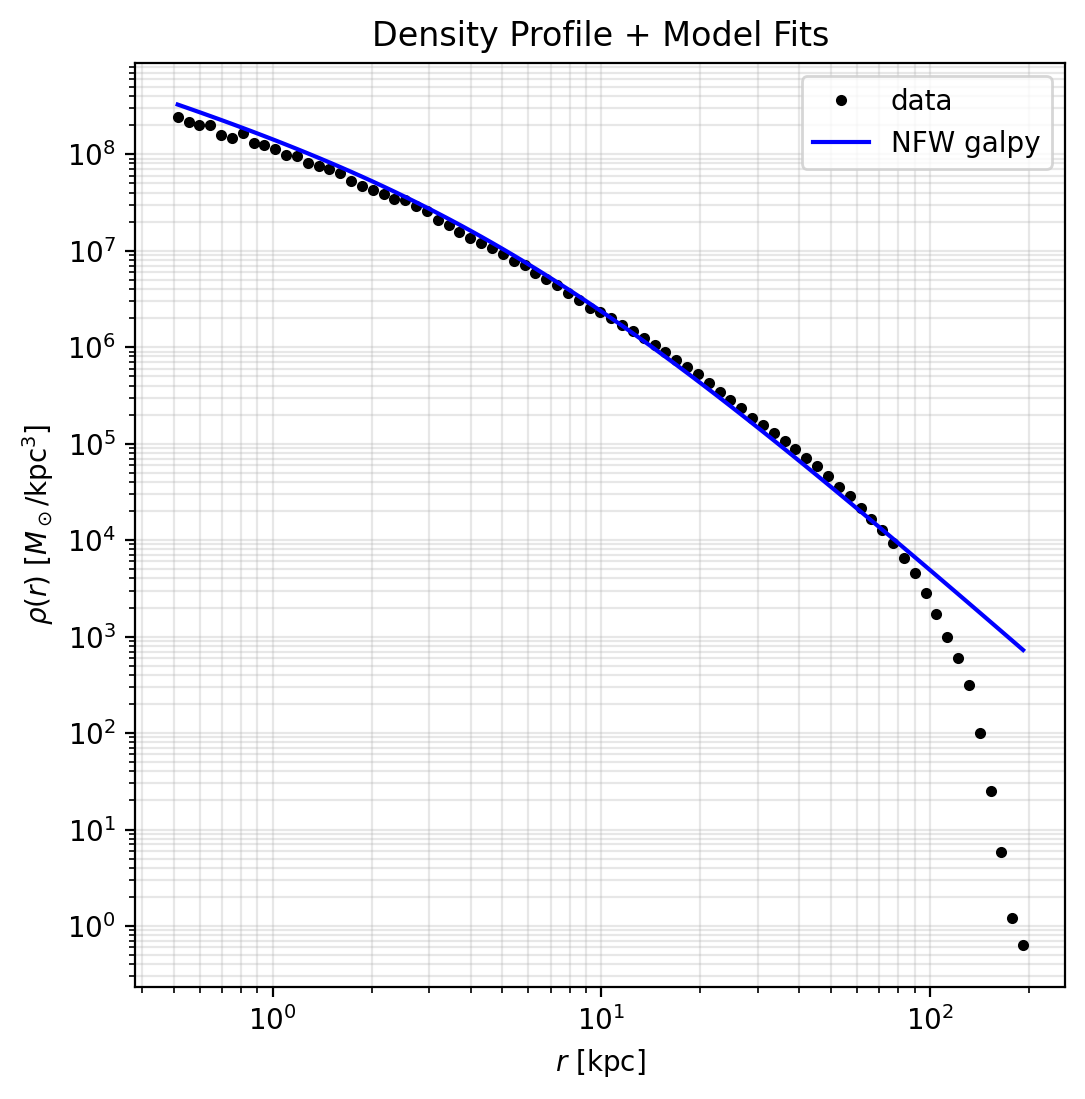

In [14]:
#Best fit model is NFW model with rho_0=3.96223131e+07, rs=5.13492391, amp=4*np.pi*rho_0_best*rs_best**3 (galpy vs book)
rho_0_best = 3.96223131e+07*(u.Msun/u.kpc**3)
rs_best = 5.13492391*u.kpc
amp = (4*np.pi*rho_0_best*rs_best**3).to(u.Msun)

NFW_potential = galpy.potential.NFWPotential(amp= amp, a = rs_best)
rho_model = NFW_potential.dens(r_mid*u.kpc, 0*u.kpc).to(u.Msun/u.kpc**3).value  # Msun/kpc^3

#check to see if the Galpy density corresponds to what we fitted
plt.figure(figsize=(6,6), dpi = 200)

plt.loglog(r_mid, rho_data, "k.", label="data")
plt.loglog(r_mid, rho_model, label="NFW galpy", color = 'blue')

plt.xlabel(r"$r$ [kpc]")
plt.ylabel(r"$\rho(r)$ [$M_\odot / \mathrm{kpc}^3$]")
plt.title("Density Profile + Model Fits")
plt.legend()
plt.grid(which= 'both', alpha=0.3)
plt.show()

Next we will look at different dynamical properties due to the potential

## a) Orbits

In [15]:
#1) Orbits
#choose a random points in the halo to simulate the orbit
def orbit_particle(index):
    x_point, y_point, z_point = (coordinates[index] - most_bound)*u.kpc
    vx_point, vy_point, vz_point = (velocities[index]-np.mean(velocities, axis=0))*(u.km/u.s)

    #change to cylindrical coordinates
    R_point = np.sqrt(x_point**2+y_point**2).to(u.kpc)
    phi_point = np.arctan2(y_point, x_point).to(u.rad)
    v_R_point = ((x_point*vx_point + y_point*vy_point)/R_point).to(u.km/u.s)
    v_T_point = ((x_point*vy_point - y_point*vx_point)/R_point).to(u.km/u.s)

    return Orbit([R_point, v_R_point, v_T_point, z_point, vz_point, phi_point])

ts = np.linspace(0 , 500 , 50000)* u.Myr
orbit_1 = orbit_particle(10)
orbit_2 = orbit_particle(100)

orbit_1.integrate(ts, NFW_potential)
orbit_2.integrate(ts, NFW_potential)

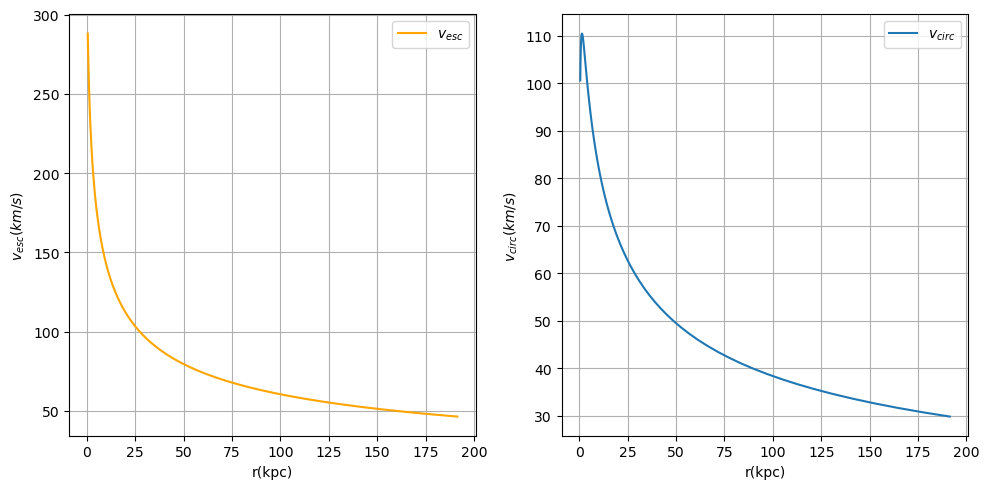

In [16]:
#Plot the escape and circular velocities
v_escape = NFW_potential.vesc(r_mid).to(u.km/u.s)
v_circular = NFW_potential.vcirc(r_mid).to(u.km/u.s)

fig, axs = plt.subplots(1,2, figsize=(10,5))

axs[0].plot(r_mid, v_escape, label=r"$v_{esc}$", color = 'orange')
axs[0].set_xlabel("r(kpc)")
axs[0].set_ylabel(r"$v_{esc}(km/s)$")
axs[0].legend()
axs[0].grid()

axs[1].plot(r_mid, v_circular, label=r"$v_{circ}$")
axs[1].set_xlabel("r(kpc)")
axs[1].set_ylabel(r"$v_{circ}(km/s)$")
axs[1].legend()
axs[1].grid()

fig.tight_layout()
plt.savefig('Images/escape_and_circular_velocities.png')
plt.show()

C:\Users\grego\AppData\Local\Temp\ipykernel_17008\3487229460.py:45: UserWarning: The figure layout has changed to tight
  fig.tight_layout()



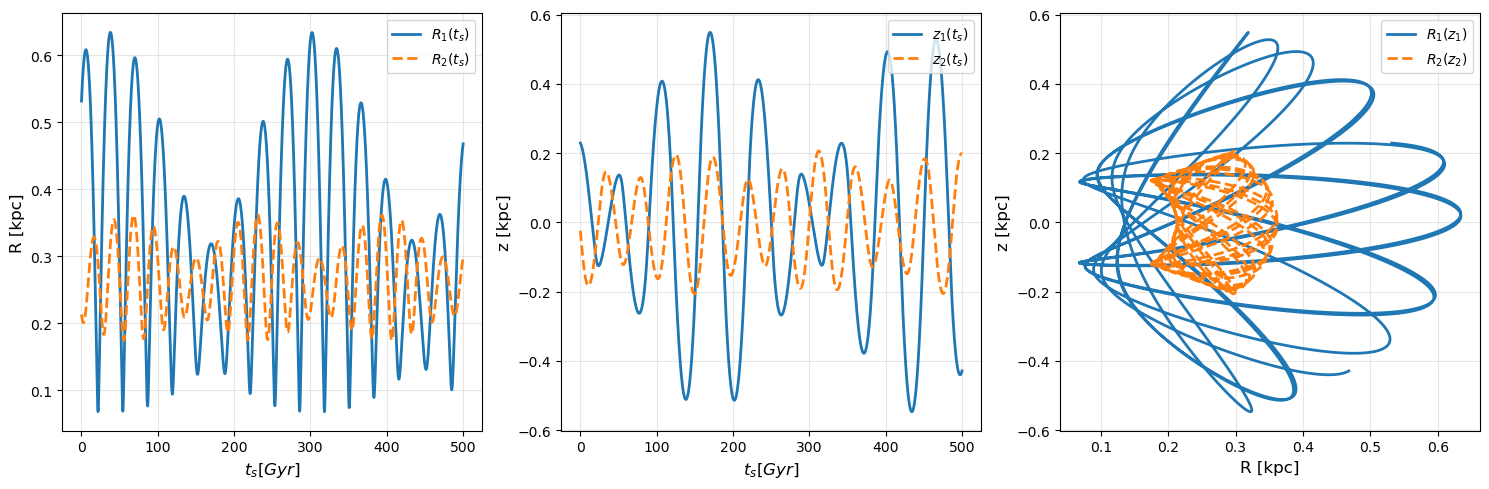

In [17]:
#outside particle
R1 = orbit_1.R(ts) #cylindrical radius, not radial!
z1 = orbit_1.z(ts)
x1 = orbit_1.x(ts)
y1 = orbit_1.y(ts)

#inside particle
R2 = orbit_2.R(ts) #cylindrical radius, not radial!
z2 = orbit_2.z(ts)
x2 = orbit_2.x(ts)
y2 = orbit_2.y(ts)

pericenter_1 = orbit_1.rperi()
apocenter_1 = orbit_1.rap()
pericenter_2 = orbit_2.rperi()
apocenter_2 = orbit_2.rap()

#plot the orbits
fig, axs = plt.subplots(1,3, figsize=(15,5), constrained_layout=True)

axs[0].plot(ts, R1, lw=2, label = r'$R_{1}(t_s)$')
axs[0].plot(ts, R2, lw=2, ls='--', label = r'$R_{2}(t_s)$')
axs[0].set_xlabel(r'$t_s [Gyr]$', fontsize=12)
axs[0].set_ylabel('R [kpc]', fontsize=12)
axs[0].legend(loc='upper right', fontsize=10)
axs[0].grid(alpha=0.3)
axs[0].tick_params(axis='both', labelsize=10)

axs[1].plot(ts, z1, lw=2, label = r'$z_{1}(t_s)$')
axs[1].plot(ts, z2, lw=2, ls='--', label = r'$z_{2}(t_s)$')
axs[1].set_xlabel(r'$t_s [Gyr]$', fontsize=12)
axs[1].set_ylabel('z [kpc]', fontsize=12)
axs[1].legend(loc='upper right', fontsize=10)
axs[1].grid(alpha=0.3)
axs[1].tick_params(axis='both', labelsize=10)

axs[2].plot(R1, z1, lw=2, label = r'$R_{1}(z_{1})$')
axs[2].plot(R2, z2, lw=2, ls='--', label = r'$R_{2}(z_{2})$')
axs[2].set_xlabel('R [kpc]', fontsize=12)
axs[2].set_ylabel('z [kpc]', fontsize=12)
axs[2].legend(loc='upper right', fontsize=10)
axs[2].grid(alpha=0.3)
axs[2].tick_params(axis='both', labelsize=10)

fig.tight_layout()
plt.savefig('Images/orbits.png', dpi=300)
plt.show()

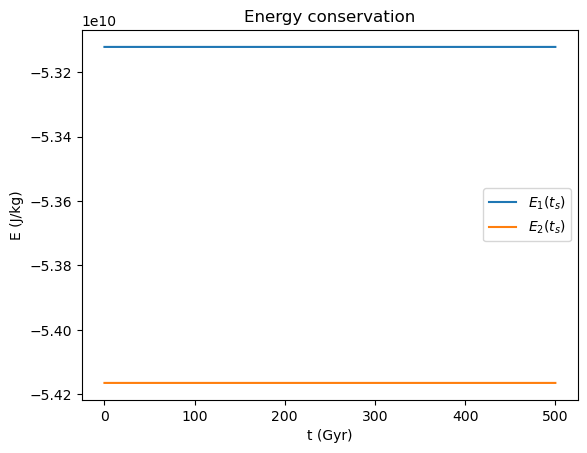

In [18]:
#check energy conservation

plt.plot(ts, orbit_1.E(ts).to(u.J/u.kg), label=r"$E_{1}(t_s)$")
plt.plot(ts, orbit_2.E(ts).to(u.J/u.kg), label=r"$E_{2}(t_s)$")
plt.xlabel('t (Gyr)')
plt.ylabel('E (J/kg)')
plt.title("Energy conservation")
plt.legend()
plt.savefig('Images/energy_conservation.png')
plt.show()

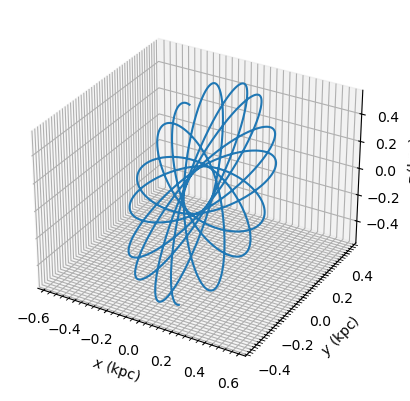

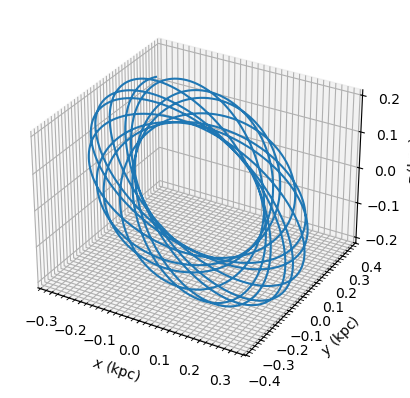

In [19]:
#also chech the vertical direction
orbit_1.plot3d()
orbit_2.plot3d()
#plt.plot([orbit_1.R().to_value()],[orbit_1.z().to_value()],'ro')
#plt.plot([orbit_2.R().to_value()],[orbit_2.z().to_value()],'ro')
plt.savefig('Images/orbits_3d.png')
plt.show()

In [20]:
orbit_1.animate3d()

In [21]:
#other dynamical properties

orbit = orbit_1 #change for one of the orbits for now
#1) Eccentricity
e = orbit.e()

#2) max_z
z_max = orbit.zmax()

#3) Pericenter/Apocenter
pericenter = orbit.rperi()
apocenter = orbit.rap()

#4) periods
azimuthal_period = orbit.Tp()
radial_period = orbit.Tr()

#5) frequencies (2pi/periods)
azimuthal_frequency = orbit.Op()
vertical_frequency = orbit.Oz()
radial_frequency = orbit.Or()

#6) Angular momentum
angular_momentum = orbit.L(ts)

#7) azimuthal angle
azimuthal_angle = orbit.phi(ts)

#8) polar angle
polar_angle = orbit.theta(ts)

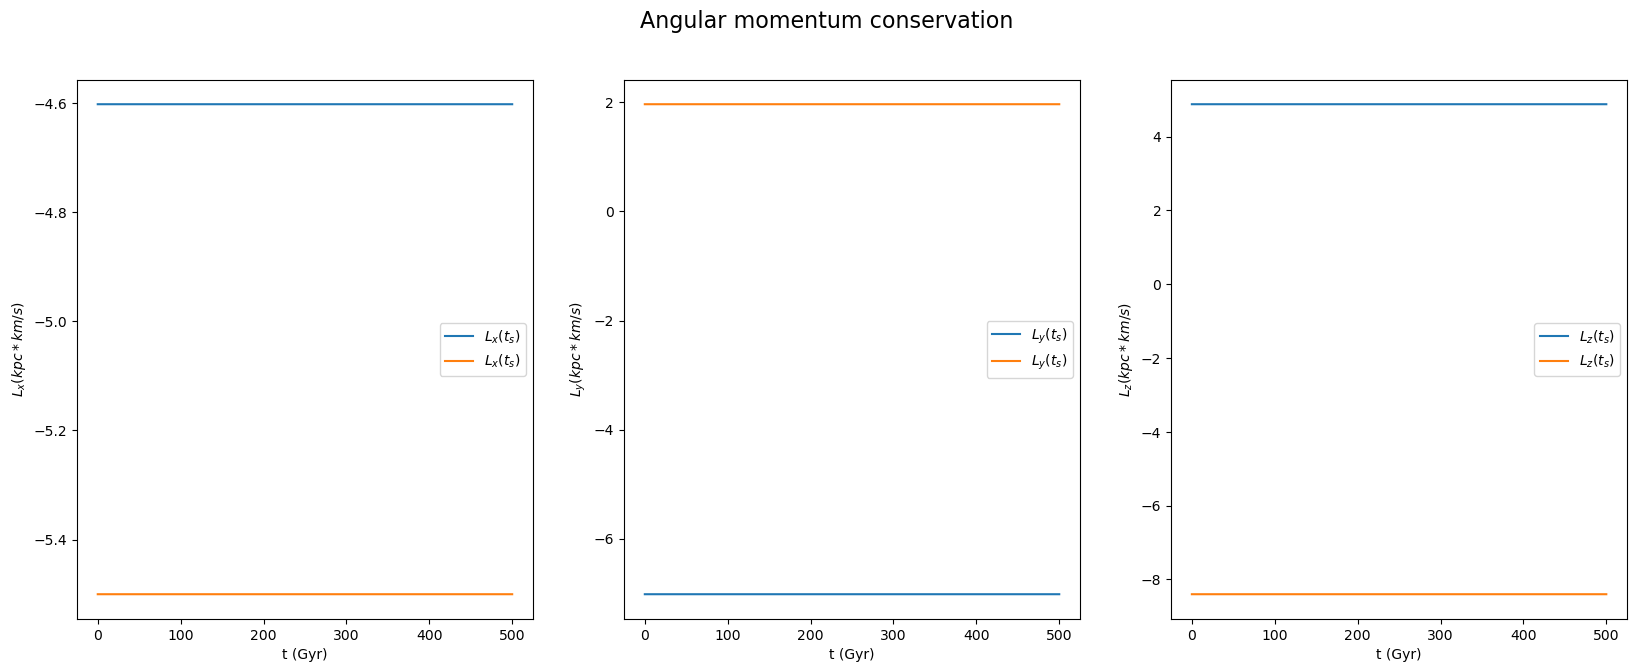

In [22]:
#check angular momentum conservation
xyz = ['x', 'y', 'z']
fig, axs = plt.subplots(1,3, figsize=(20,7))

for i in range(3):
    axs[i].plot(ts, orbit_1.L(ts).to(u.kpc*u.km/u.s)[:, i], label=rf"$L_{xyz[i]}(t_s)$")
    axs[i].plot(ts, orbit_2.L(ts).to(u.kpc*u.km/u.s)[:, i], label=rf"$L_{xyz[i]}(t_s)$")
    axs[i].set_xlabel('t (Gyr)')
    axs[i].set_ylabel(rf'$L_{xyz[i]}(kpc*km/s)$')
    axs[i].legend()

fig.suptitle('Angular momentum conservation', fontsize=16)
plt.savefig('Images/angular_momentum_conservation.png')
plt.show()

# Part 4) Rotation curves 

For a spherical system, the rotation velocity at radius $r$ is estimated directly from the velocity as:
\begin{equation}
v_c(r) = \sqrt{\langle v^2_{\phi}\rangle},
\end{equation} 
where $v_{\phi}$ is the tangential velocity around the halo center.



In [23]:
from galpy.potential import HernquistPotential


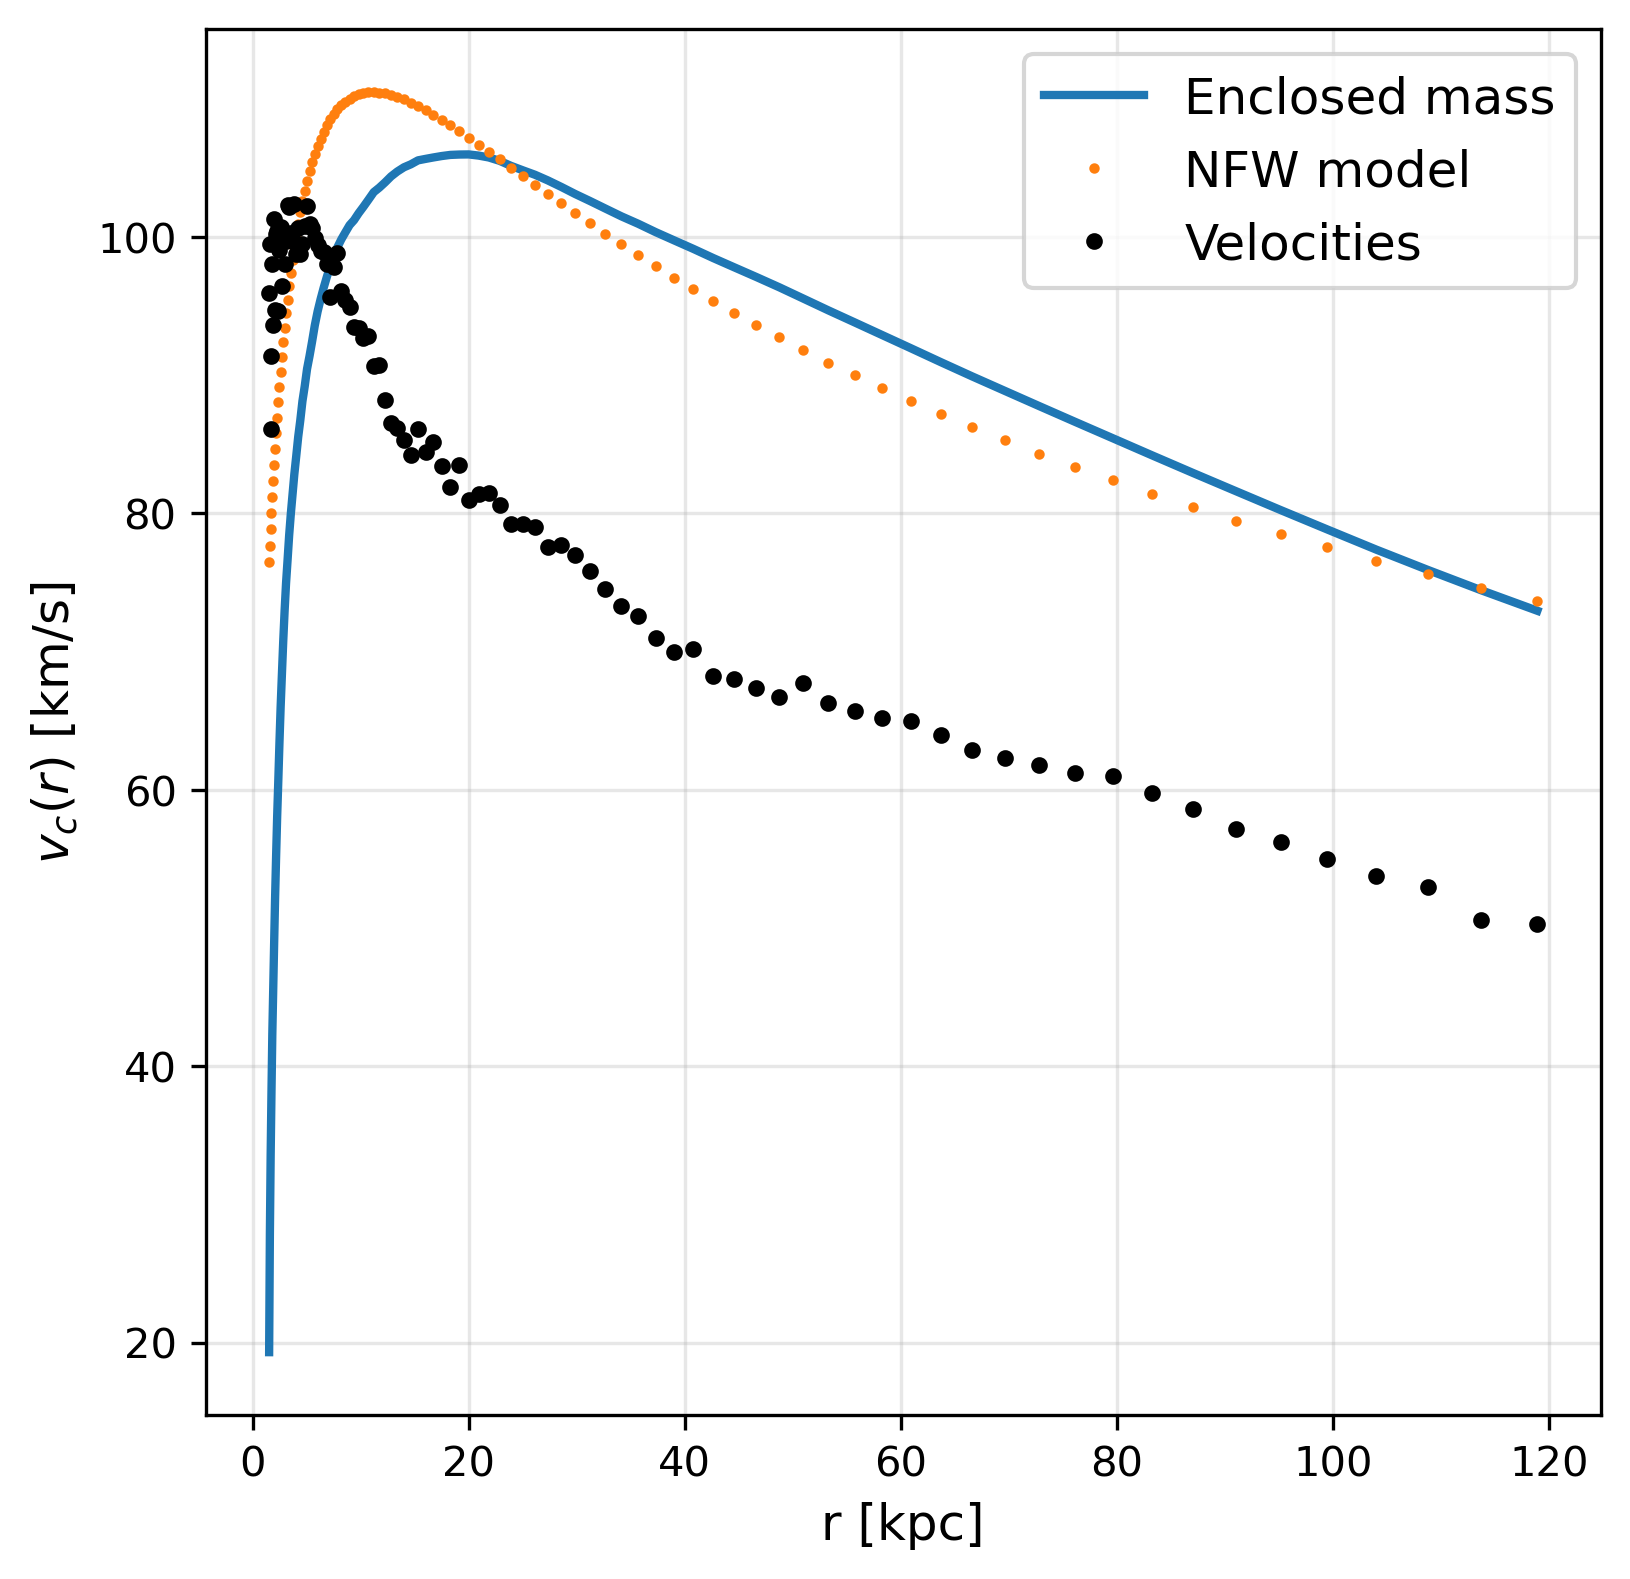

In [24]:
#shift coordinate system around center
pos = coordinates-most_bound
# subtract bulk halo motion
vel = velocities - np.mean(velocities, axis=0)  

#take distance from center (most bound particle)
r = radius_particles


# Remove r = 0 particles (center particle)
mask_nonzero = r > 0
pos = pos[mask_nonzero]
vel = vel[mask_nonzero]
r  = r[mask_nonzero]

# Unit radial vectors
r_hat = pos / r[:, None]

# Radial velocity component v_r
v_r = np.sum(vel * r_hat, axis=1)

# Tangential velocity squared v_t^2 = v^2 - v_r^2, if circular orbits, v_t = v_c
v2 = np.sum(vel**2, axis=1)
v_t2 = v2 - v_r**2
v_r2 = v_r**2


#Put r in log-bins
N_bins = 100
r_min = np.percentile(r, 1)    # ignore exact zero
r_max = np.percentile(r, 99)   # trim extreme outliers
r_bins = np.logspace(np.log10(r_min), np.log10(r_max), N_bins)
r_mid_mask = np.sqrt(r_bins[1:] * r_bins[:-1])


#Assigns each particle to a radial bin
bin_idx = np.digitize(r, r_bins) - 1

# Keep only valid bin assignments (bugfix -> gave errors)
valid = (bin_idx >= 0) & (bin_idx < N_bins-1)
bin_idx = bin_idx[valid]
v_t2    = v_t2[valid]
v_r2    = v_r2[valid]


#Compute v_t^2 and counts  inside each bin
v_t2_sum = np.bincount(bin_idx, weights=v_t2, minlength=N_bins-1)[:N_bins-1]
v_r2_sum = np.bincount(bin_idx, weights=v_r2, minlength=N_bins-1)[:N_bins-1]
counts   = np.bincount(bin_idx, minlength=N_bins-1)[:N_bins-1]

# Compute circular velocity per bin as average
vc_vel = np.full(N_bins-1, np.nan)
vc_vel= np.sqrt(v_t2_sum / counts) #correct one to use
#vc_vel= np.sqrt((v_t2_sum+v_r2_sum) / counts)

#Calculate vcirc with galpy
M = m_dm*N

vc_galpy = NFW_potential.vcirc(r_mid_mask*u.kpc).to(u.km/u.s).value 
v_circular = NFW_potential.vcirc(r_mid_mask*u.kpc).to(u.km/u.s)


#Calculate enclosed mass 

cumulative_counts = np.cumsum(counts)          # particles inside r_mid
M_enc = m_dm * cumulative_counts               # Msun

# Circular velocity from enclosed mass
vc_mass = np.sqrt(G * M_enc / r_mid_mask)  # km/s

# Plot comparison
plt.figure(figsize=(6,6), dpi=300)
plt.plot(r_mid_mask, vc_mass, '-', lw=2, label='Enclosed mass')
plt.plot(r_mid_mask, vc_galpy, '.', ms=3, label='NFW model')
plt.plot(r_mid_mask, vc_vel, 'k.', label="Velocities") 

plt.xlabel("r [kpc]", fontsize=12)
plt.ylabel(r"$v_c(r)$ [km/s]", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tick_params(which="both", labelsize=10)
plt.savefig('Images/rotationcurves.png', dpi=300)
plt.show()

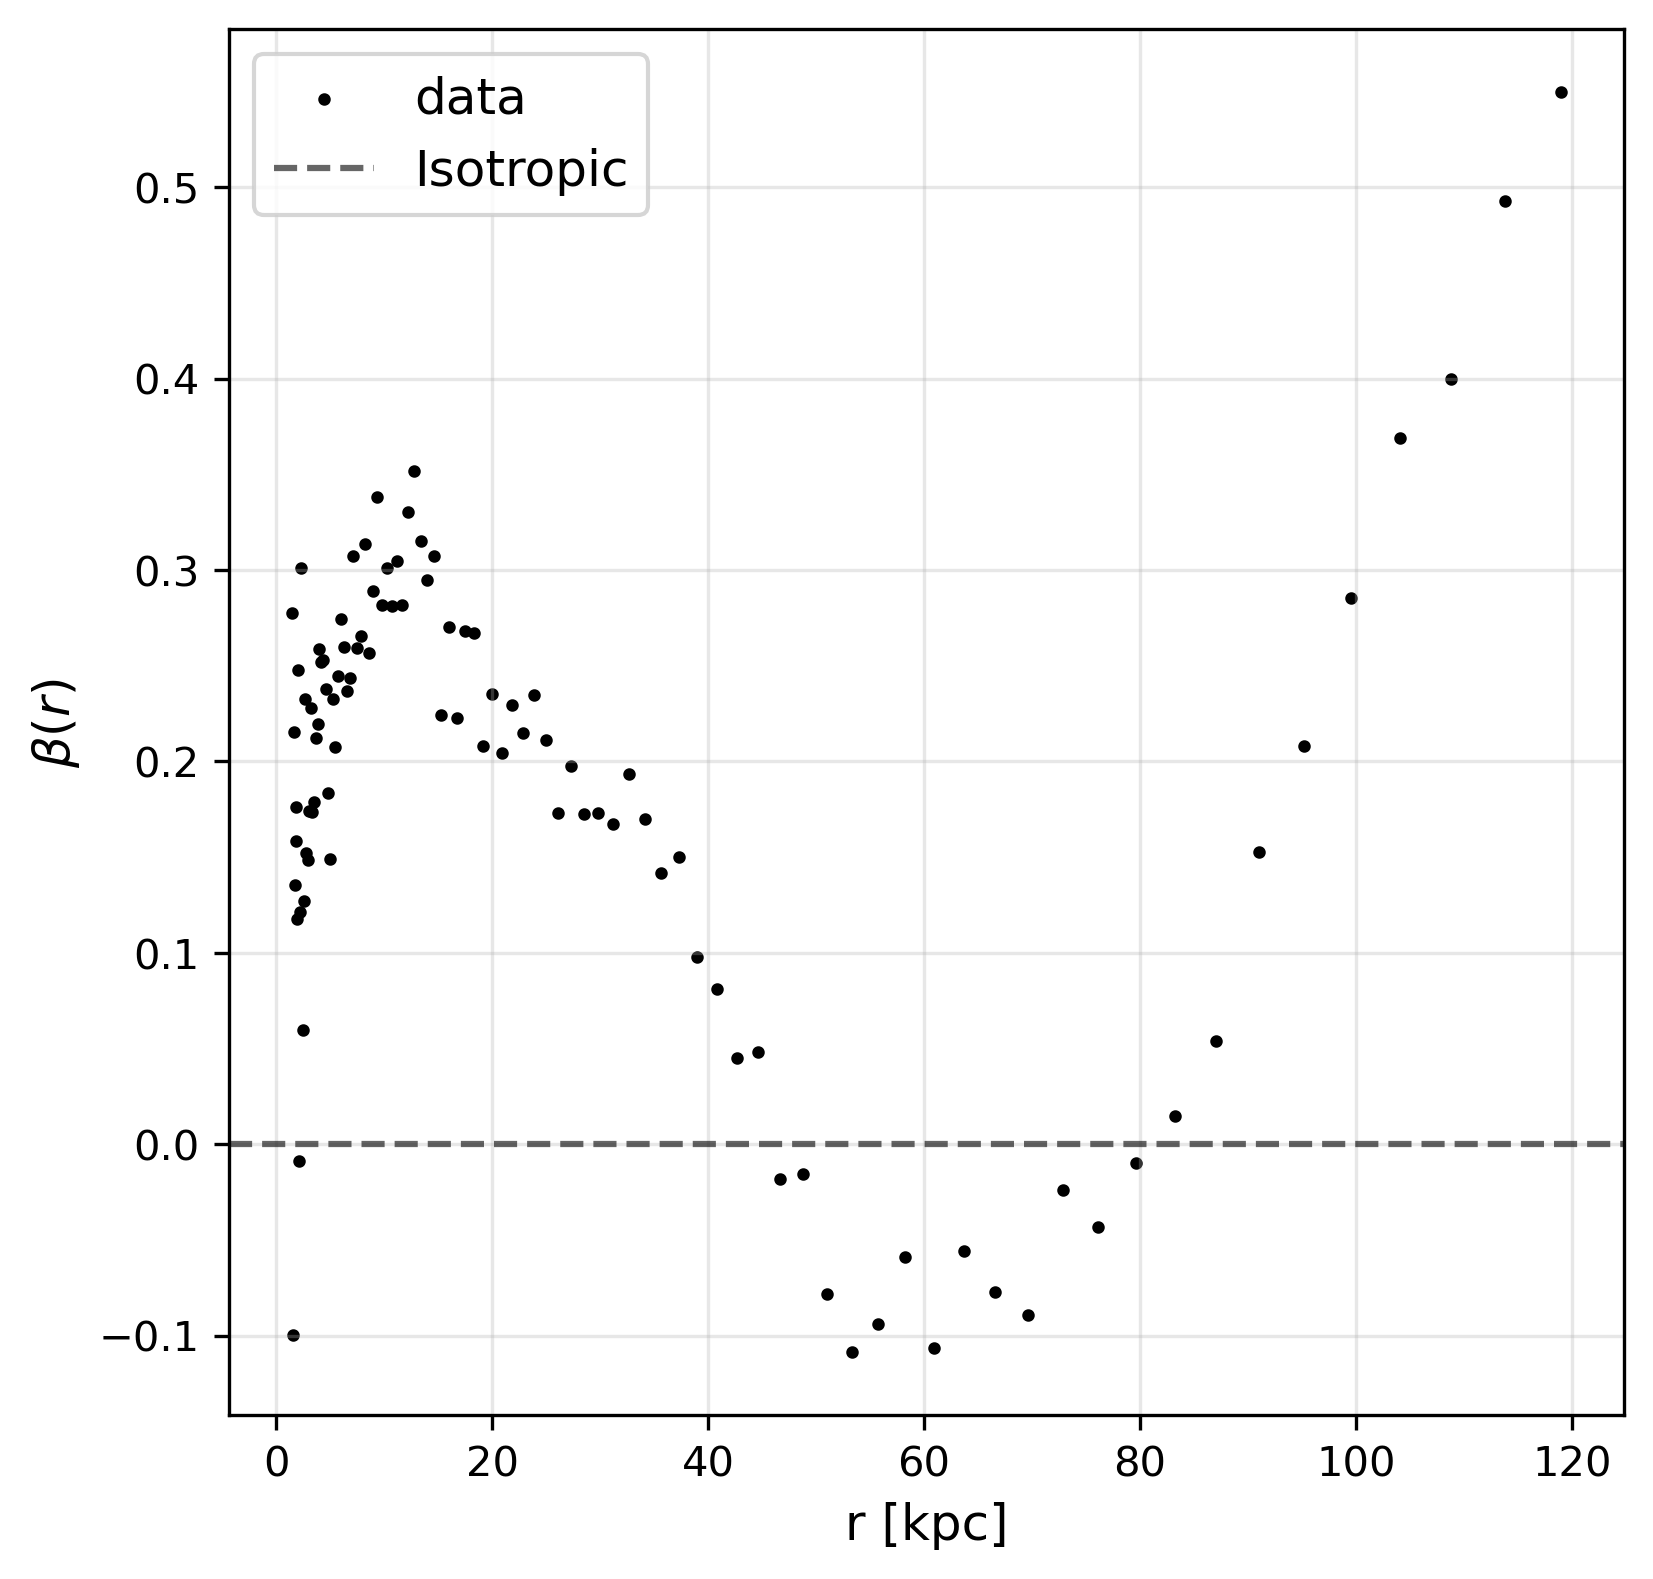

In [25]:
# --- Step 1: Radial and tangential velocity dispersions per bin ---

# sigma_r^2: radial velocity dispersion
sigma_r2_sum = np.bincount(bin_idx, weights=v_r[valid]**2, minlength=N_bins-1)[:N_bins-1]
sigma_r2 = sigma_r2_sum / counts

# sigma_t^2: tangential velocity dispersion (already summed)
sigma_t2 = v_t2_sum / counts

# --- Step 2: Velocity anisotropy beta(r) ---
beta = 1 - sigma_t2 / (2 * sigma_r2)

# Plot beta(r)
plt.figure(figsize=(6,6), dpi=300)
plt.scatter(r_mid_mask, beta, s=4, color='black', label="data")
plt.axhline(y=0, color='black', alpha=0.6, ls="--", label="Isotropic")
plt.xlabel("r [kpc]", fontsize=12)
plt.ylabel(r"$\beta(r)$", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tick_params(which="both", labelsize=10)
plt.savefig('Images/anisotropy.png', dpi=300)
plt.show()

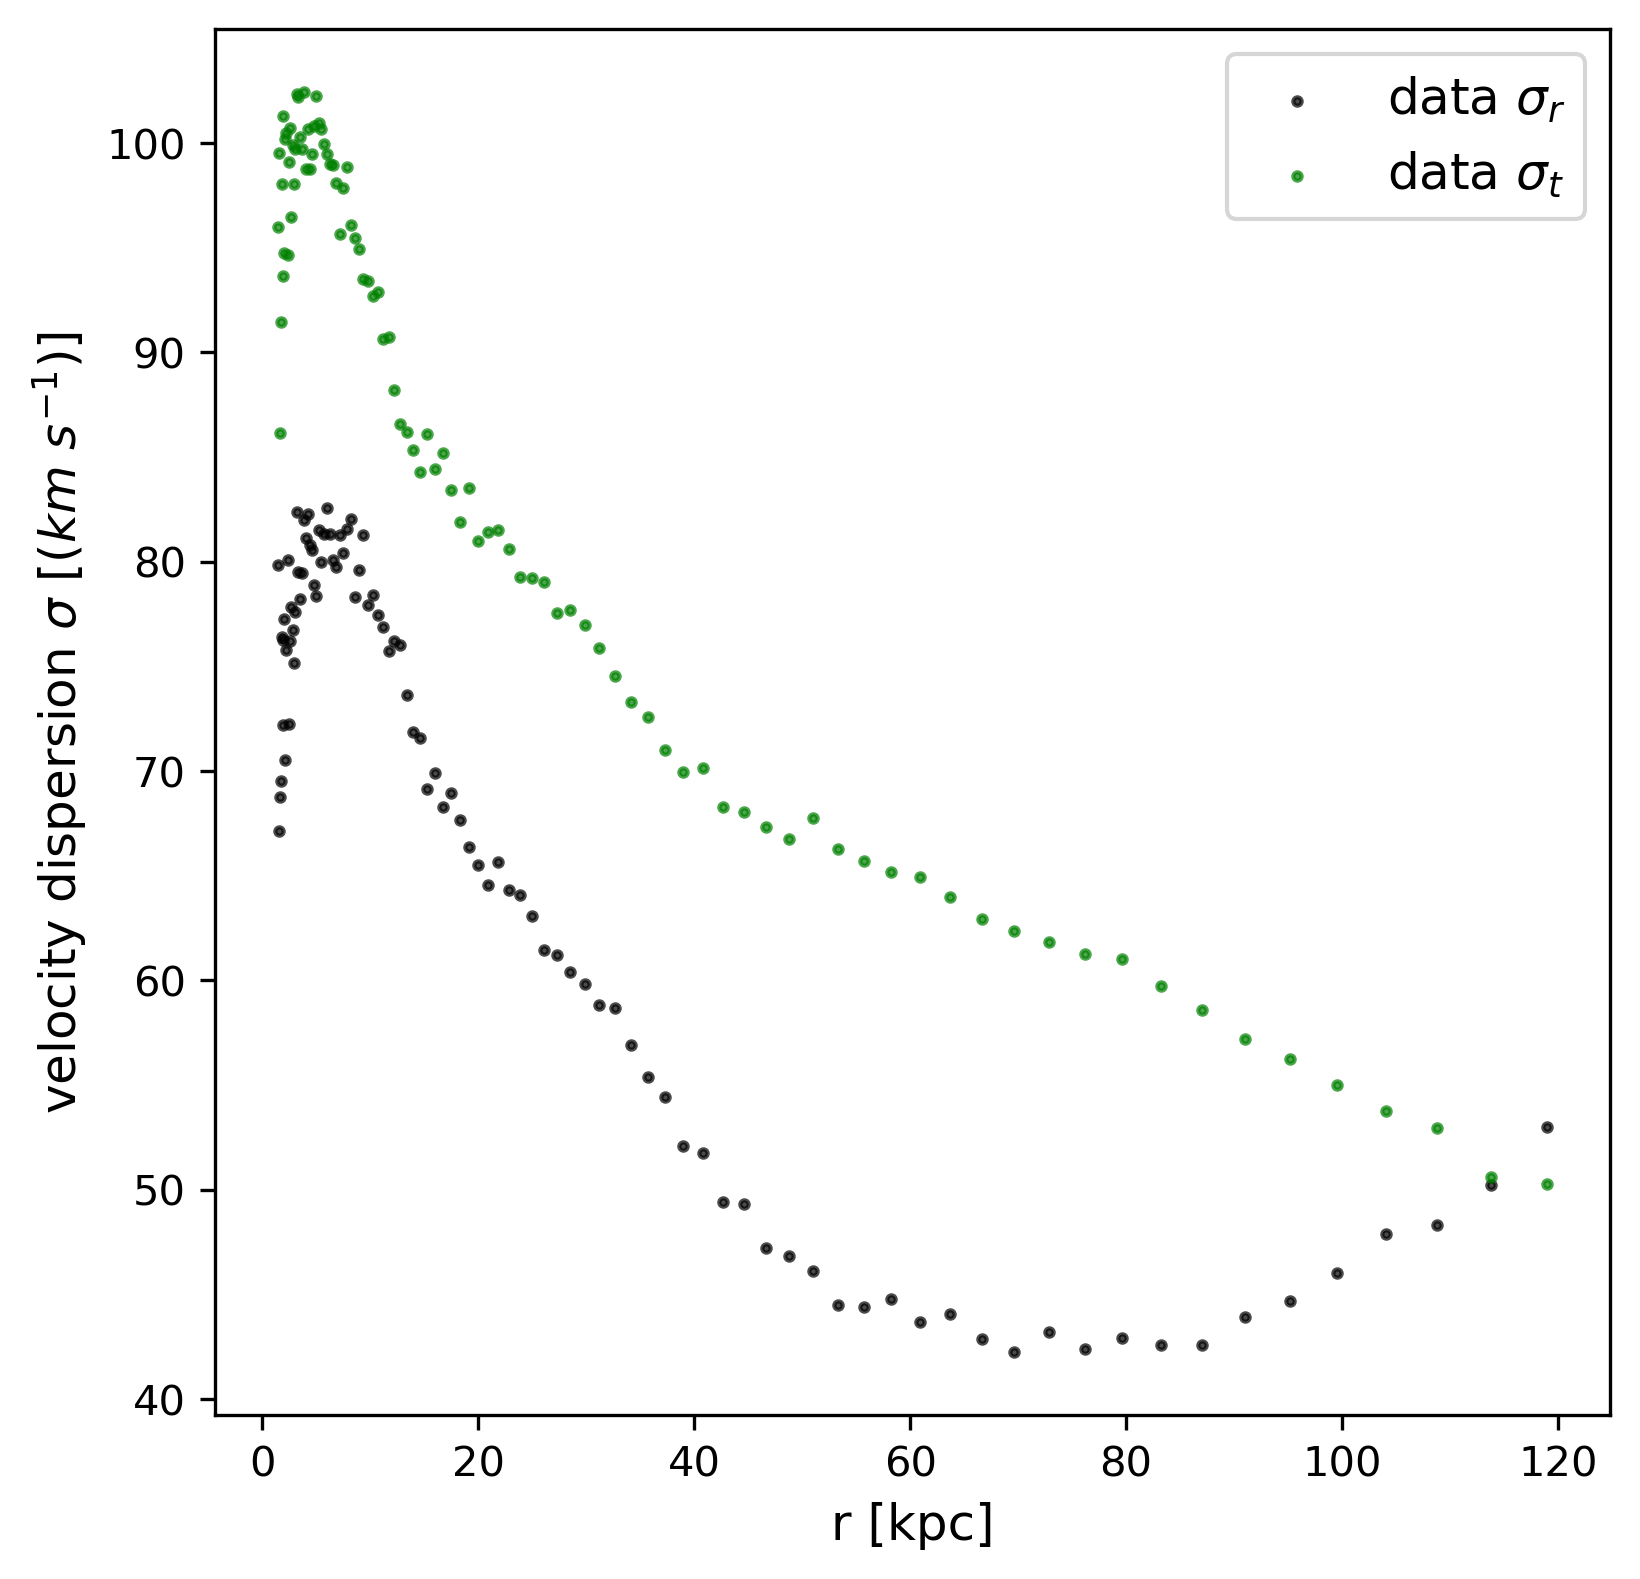

In [26]:
fig = plt.subplots(figsize=(6,6), dpi=300)

plt.scatter(r_mid_mask, np.sqrt(sigma_r2), color="black", alpha=0.7, s=4, label=r"data $\sigma_r$")
plt.scatter(r_mid_mask, np.sqrt(sigma_t2), color="green", alpha=0.7, s=4, label=r"data $\sigma_{t}$")
plt.xlabel("r [kpc]", fontsize=12)
plt.ylabel(r"velocity dispersion $\sigma\ [(km\ s^{-1})]$", fontsize=12)
plt.legend(fontsize=12)
plt.tick_params(which="both", labelsize=10)
plt.savefig("Images/velocity_dispersion.png", dpi=300)
plt.show()


In [27]:
#velocity distribution function
v2 = np.sum(vel**2, axis=1)


def velocity_distribution(v, bins=50, density=True):
    """
    Compute the velocity distribution function from velocity vectors.

    Parameters
    ----------
    vel : ndarray, shape (N, 3)
        Particle velocities (vx, vy, vz).
    bins : int
        Number of bins in the histogram.
    density : bool
        If True, returns normalized distribution.

    Returns
    -------
    bin_centers : ndarray
        Centers of velocity bins.
    f_v : ndarray
        Velocity distribution function values.
    """

    # Histogram → distribution
    f_v, edges = np.histogram(v, bins=bins, density=density)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    
    return bin_centers, f_v

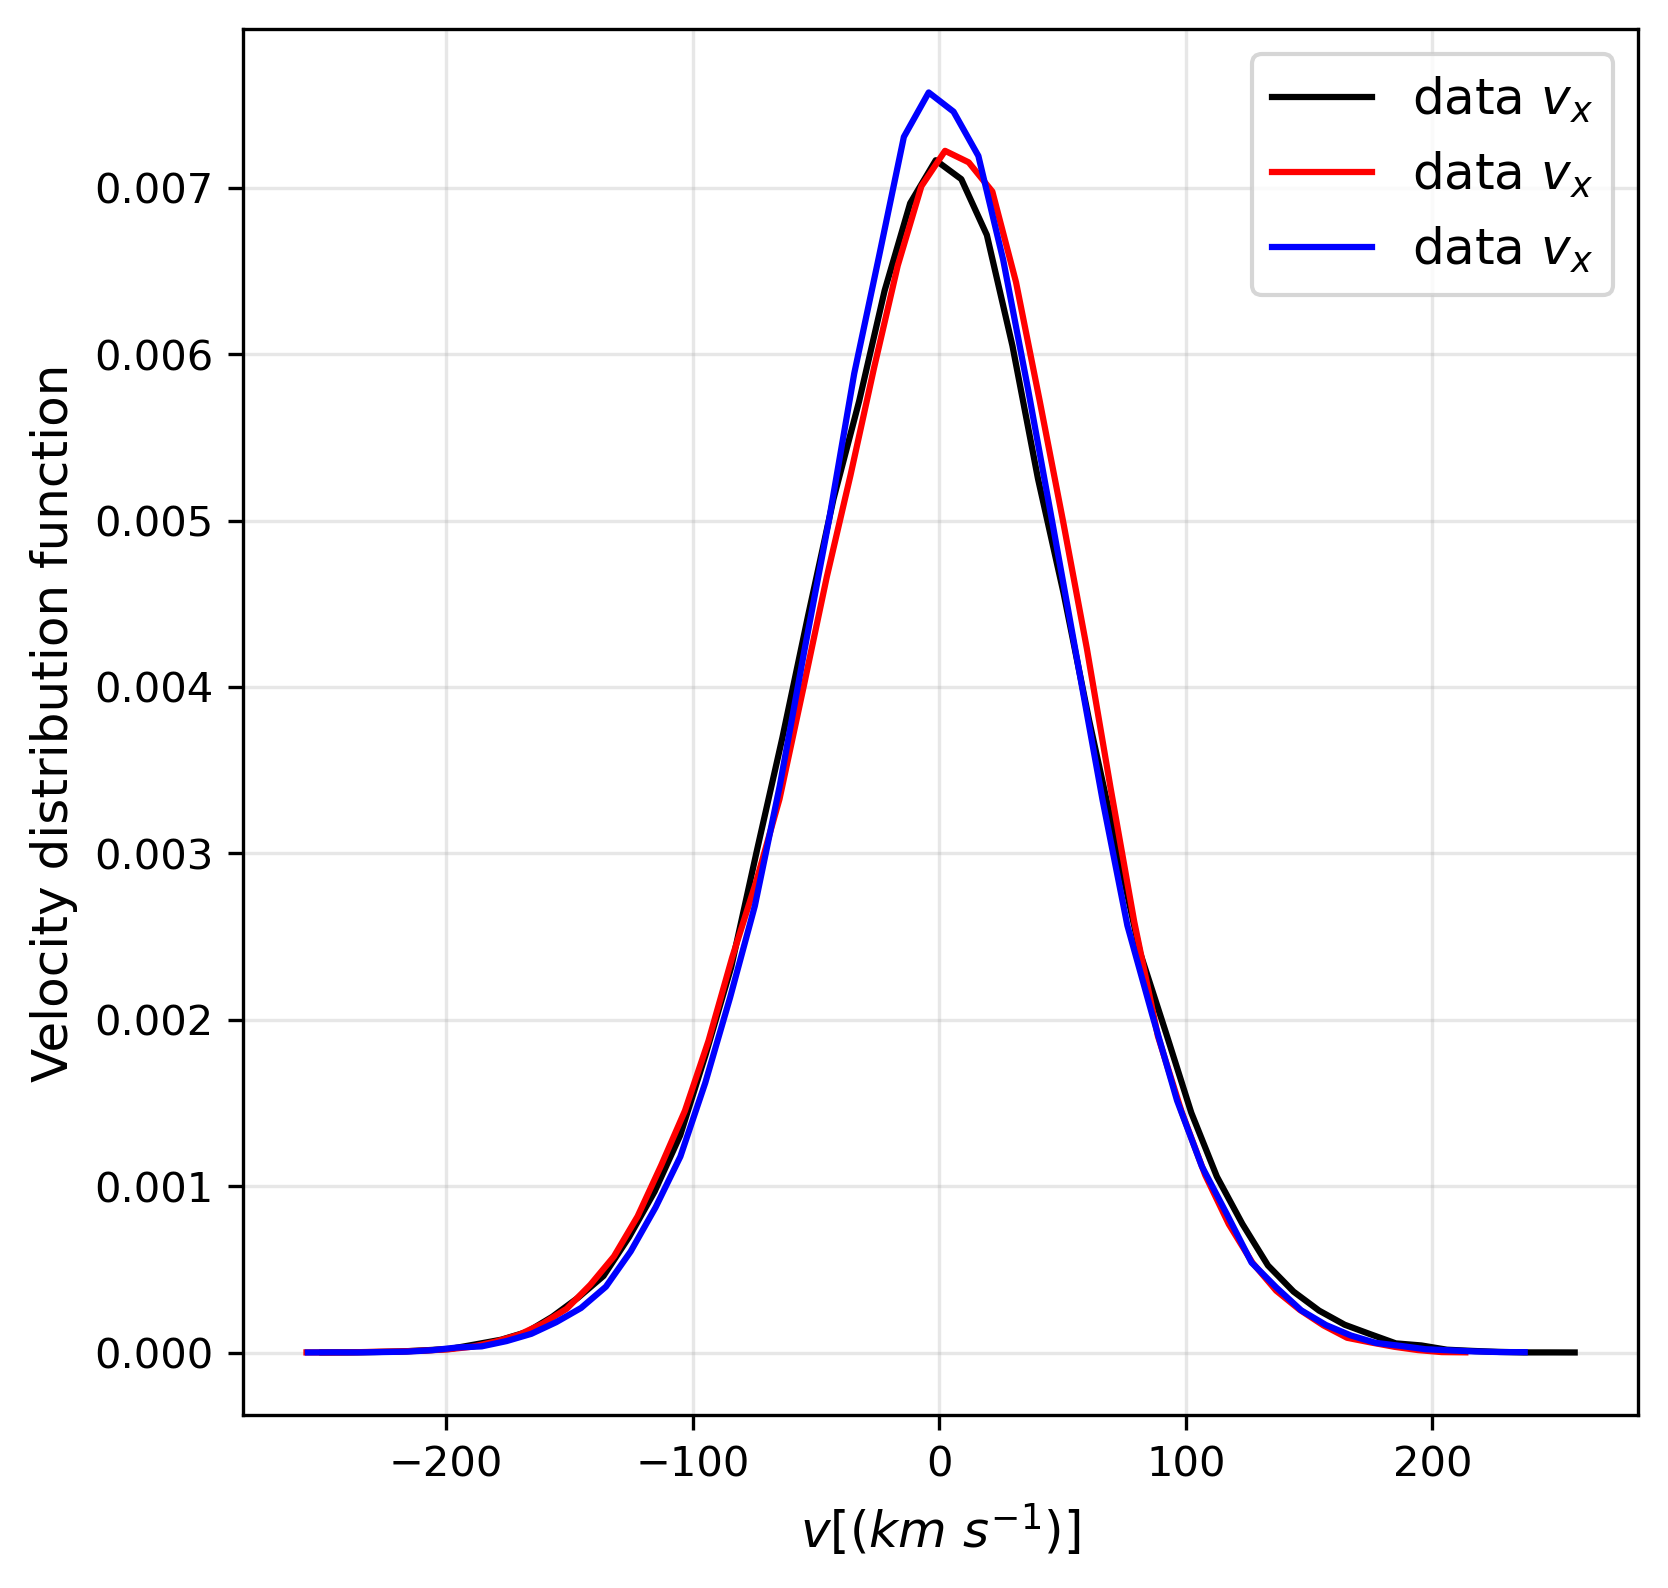

In [28]:
v_x = vel[:,0]
v_y = vel[:,1]
v_z = vel[:,2]

vx_bins, vx_values = velocity_distribution(v_x, bins=50, density=True)
vy_bins, vy_values = velocity_distribution(v_y, bins=50, density=True)
vz_bins, vz_values = velocity_distribution(v_z, bins=50, density=True)

fig = plt.subplots(figsize=(6,6), dpi=300)

plt.plot(vx_bins, vx_values, color="black", label=r"data $v_x$")
plt.plot(vy_bins, vy_values, color="red", label=r"data $v_x$")
plt.plot(vz_bins, vz_values, color="blue", label=r"data $v_x$")

plt.xlabel(r"$v [(km\ s^{-1})]$", fontsize=12)
plt.ylabel("Velocity distribution function", fontsize=12)
plt.legend(fontsize=12)
plt.tick_params(which="both", labelsize=10)
plt.grid(alpha=0.3)
plt.savefig("Images/velocity_distribution.png", dpi=300)
plt.show()

In [29]:
#Define Gaussian
def gaussian(v, A, mu, sigma):
    return A * np.exp(-(v - mu)**2 / (2 * sigma**2))

#Fit Gaussian
def fit_gaussian(bin_centers, f_v):
    # Initial guesses
    mu0 = np.sum(bin_centers * f_v) / np.sum(f_v)
    sigma0 = np.sqrt(np.sum((bin_centers - mu0)**2 * f_v) / np.sum(f_v))
    A0 = f_v.max()

    popt, pcov = curve_fit(
        gaussian,
        bin_centers,
        f_v,
        p0=[A0, mu0, sigma0]
    )

    return popt, pcov

#Get parameters for each component
popt_vx, pcov_vx = fit_gaussian(vx_bins, vx_values)
popt_vy, pcov_vy = fit_gaussian(vy_bins, vy_values)
popt_vz, pcov_vz = fit_gaussian(vz_bins, vz_values)

A_vx, mu_vx, sigma_vx = popt_vx
A_vy, mu_vy, sigma_vy = popt_vy
A_vz, mu_vz, sigma_vz = popt_vz

A_vx_cov, mu_vx_cov, sigma_vx_cov = pcov_vx
A_vy_cov, mu_vy_cov, sigma_vy_cov = pcov_vy
A_vz_cov, mu_vz_cov, sigma_vz_cov = pcov_vz

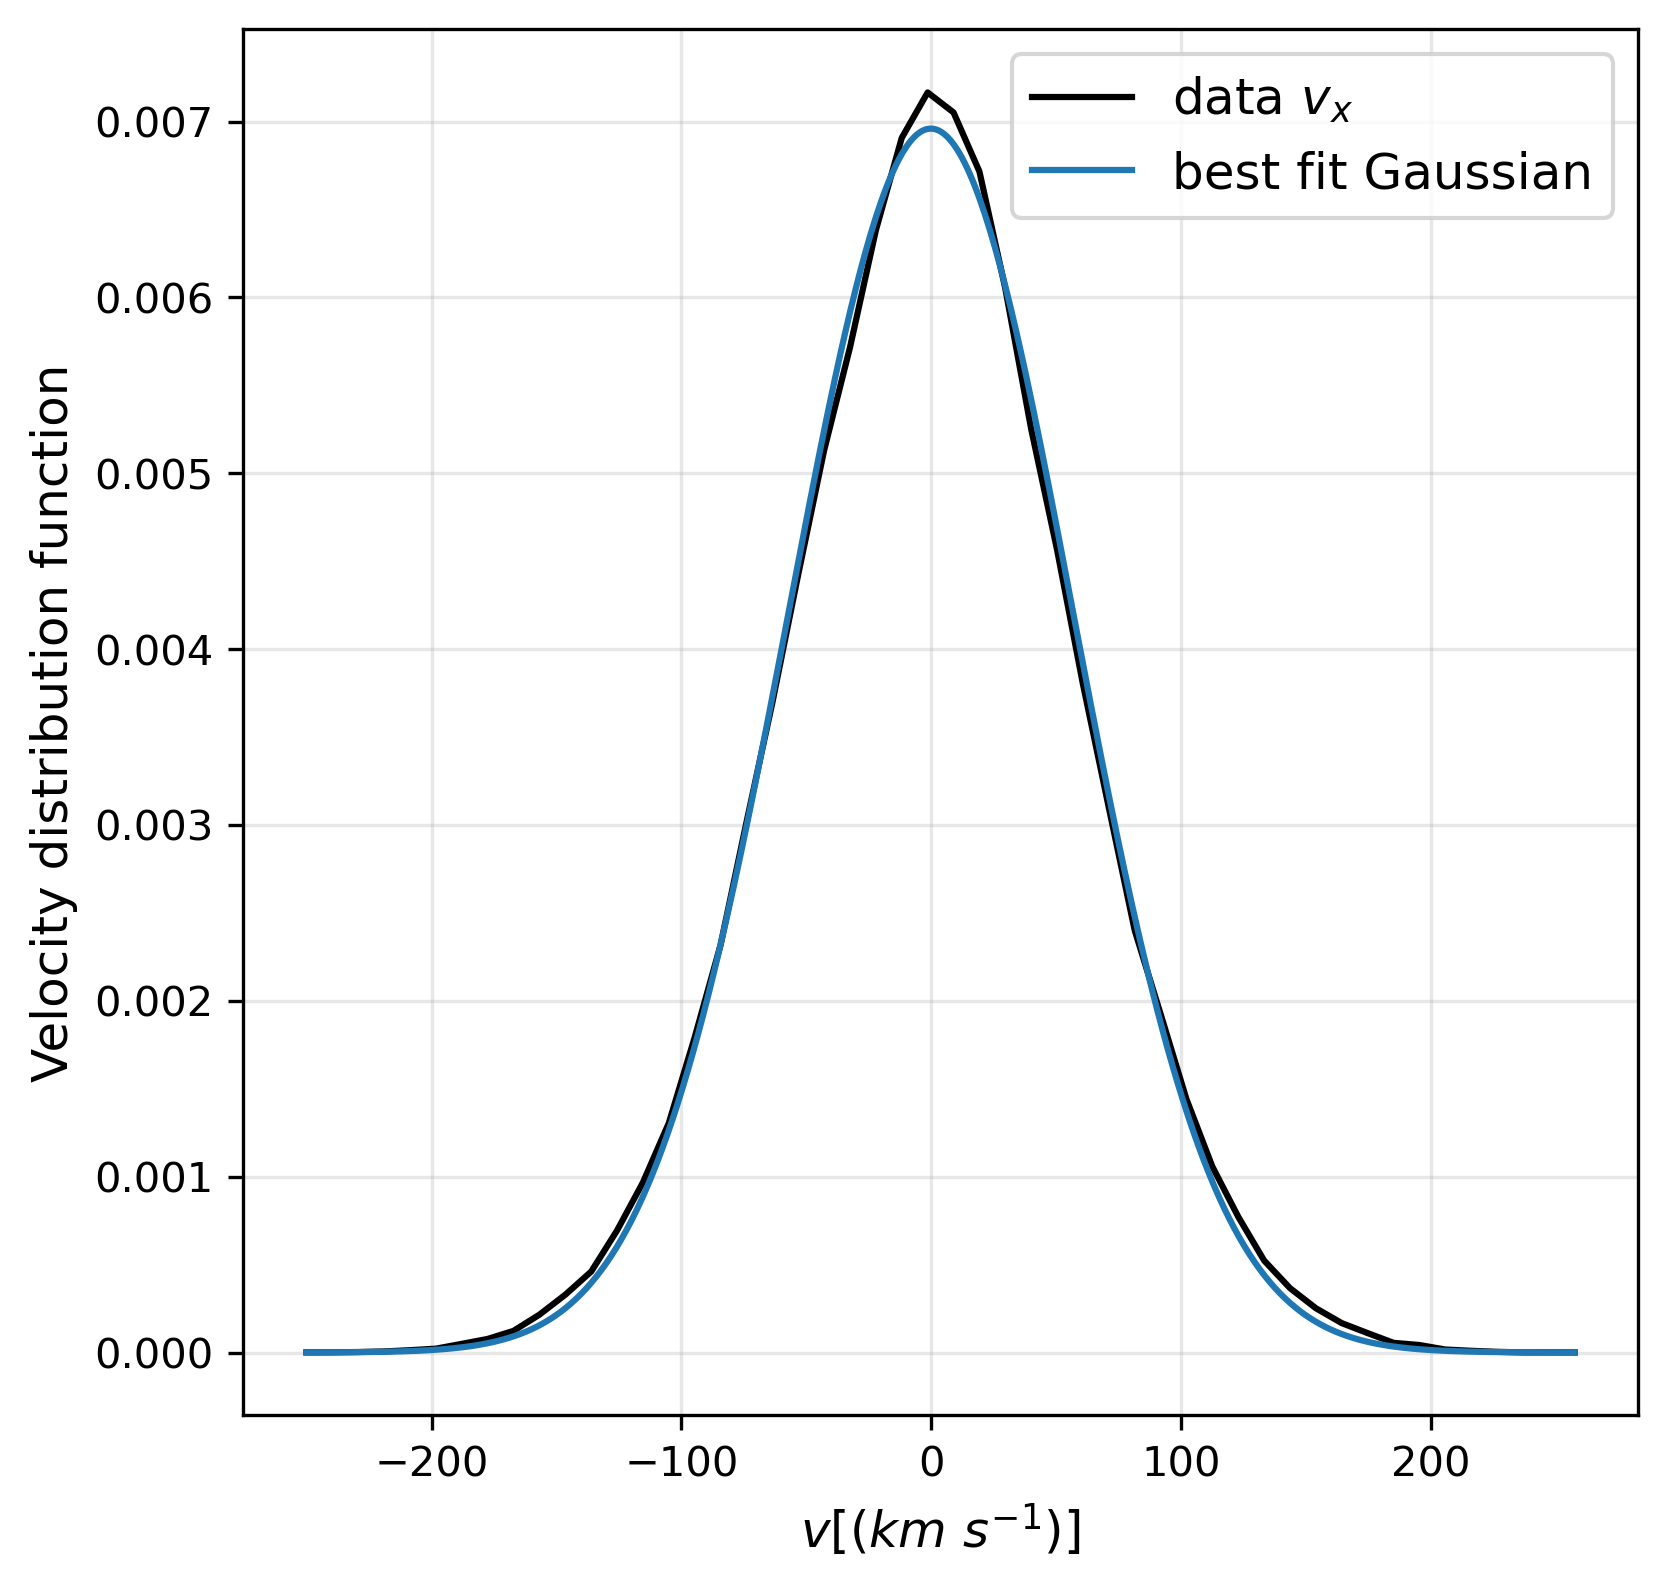

In [30]:
#plot fot v_x
v_plot = np.linspace(vx_bins.min(), vx_bins.max(), 500)

fig = plt.subplots(figsize=(6,6), dpi=300)

plt.plot(vx_bins, vx_values, color="black", label=r"data $v_x$")
plt.plot(v_plot, gaussian(v_plot, A_vx, mu_vx, sigma_vx), label="best fit Gaussian")

plt.xlabel(r"$v [(km\ s^{-1})]$", fontsize=12)
plt.ylabel("Velocity distribution function", fontsize=12)
plt.legend(fontsize=12)
plt.tick_params(which="both", labelsize=10)
plt.grid(alpha=0.3)
plt.savefig("Images/velocity_distribution_best_fit.png", dpi=300)
plt.show()

In [31]:
import os
import sys
import h5py
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit
import time
from tqdm import tqdm
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [32]:
#load file locally
#subhalo_file = r"C:\Users\Mathijs DeKeyser\Documents\TANA\TNG100-1_subhalosCat.hdf5"

#Greg
subhalo_file = r"C:\Users\grego\OneDrive\Documents\ugent\master\2e jaar\TANA paper\TNG100-1_subhalosCat.hdf5 (2)\TNG100-1_subhalosCat.hdf5"

In [33]:
data = h5py.File(subhalo_file, 'r')
data.keys()

<KeysViewHDF5 ['Config', 'Header', 'Parameters', 'Subhalo']>

In [34]:
#All attributes
print("Header")
for x in list(data['Header'].attrs):
    print(f'The value for {x} is: {data['Header'].attrs[x]}')


print("Parameters")
for x in list(data['Parameters'].attrs):
    print(f'The value for {x} is: {data['Parameters'].attrs[x]}')

print("Subhalo")
for x in list(data['Subhalo'].attrs):
    print(f'The value for {x} is: {data['Subhalo'].attrs[x]}')

Header
The value for BoxSize is: 75000.0
The value for HubbleParam is: 0.6774
The value for Nsubgroups_Total is: 4371211
The value for Omega0 is: 0.3089
The value for OmegaLambda is: 0.6911
The value for Redshift is: 2.220446049250313e-16
The value for Time is: 0.9999999999999998
Parameters
The value for AGB_MassTransferOn is: 1
The value for ActivePartFracForNewDomainDecomp is: 0.003
The value for AdaptiveHydroSofteningSpacing is: 1.2
The value for BlackHoleAccretionFactor is: 1.0
The value for BlackHoleCenteringMassMultiplier is: 1000.0
The value for BlackHoleEddingtonFactor is: 1.0
The value for BlackHoleFeedbackFactor is: 0.1
The value for BlackHoleMaxAccretionRadius is: 1e+20
The value for BlackHoleRadiativeEfficiency is: 0.2
The value for BoxSize is: 75000.0
The value for CellMaxAngleFactor is: 2.25
The value for CellShapingSpeed is: 0.5
The value for ComovingIntegrationOn is: 1
The value for CoolingOn is: 1
The value for CoolingTablePath is: b'L75TNG_Arepo_GFM_Tables/Cooling/coo

In [35]:
#information on subhalos

for el in list(data['Subhalo'].keys()):
    print(f"The value of {el} is: {data['Subhalo'][el]}")

The value of SubhaloBHMass is: <HDF5 dataset "SubhaloBHMass": shape (4371211,), type "<f4">
The value of SubhaloBHMdot is: <HDF5 dataset "SubhaloBHMdot": shape (4371211,), type "<f4">
The value of SubhaloBfldDisk is: <HDF5 dataset "SubhaloBfldDisk": shape (4371211,), type "<f4">
The value of SubhaloBfldHalo is: <HDF5 dataset "SubhaloBfldHalo": shape (4371211,), type "<f4">
The value of SubhaloCM is: <HDF5 dataset "SubhaloCM": shape (4371211, 3), type "<f4">
The value of SubhaloFlag is: <HDF5 dataset "SubhaloFlag": shape (4371211,), type "|b1">
The value of SubhaloGasMetalFractions is: <HDF5 dataset "SubhaloGasMetalFractions": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsHalfRad is: <HDF5 dataset "SubhaloGasMetalFractionsHalfRad": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsMaxRad is: <HDF5 dataset "SubhaloGasMetalFractionsMaxRad": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsSfr is: <HDF5 dataset "SubhaloGasMet

In [36]:
#extract useful data
h = data['Header'].attrs['HubbleParam'] #Hubble parameter
boxsize = data['Header'].attrs['BoxSize']/h #boxsize in comoving kpc (~110MPc)
mask   = np.asarray(data['Subhalo']['SubhaloFlag'], dtype=np.uint8) #consider for analysis (halo is suitable for analysis)
pos = np.asarray(data['Subhalo']['SubhaloPos'])/h #kpc most bound particle
COM = np.asarray(data['Subhalo']['SubhaloCM'])/h #COM of halos
total_mass_type = np.asarray(data['Subhalo']["SubhaloMassType"][:])*10**10/h # Total Mass of all bound particles per type
total_mass  = np.asarray(data['Subhalo']["SubhaloMass"][:])*10**10/h  #Total mass of all particles all types combined
subhalo_len = np.asarray(data['Subhalo']["SubhaloLen"][:]) #Total number of member particle/cells in this Subhalo, of all types.
subhalo_parents = np.asarray(data['Subhalo']['SubhaloParent'])
subhalo_grnr = np.asarray(data['Subhalo']['SubhaloGrNr'])
print(len(pos[:,0]))

#only take suitable for analysis (mask 1)
pos = pos[mask==1]
COM = COM[mask == 1]
total_mass_type = total_mass_type[mask == 1]
total_mass = total_mass[mask == 1]
subhalo_len = subhalo_len[mask == 1]
subhalo_parents = subhalo_parents[mask == 1]
subhalo_grnr = subhalo_grnr[mask == 1]

print(len(pos[:,0]))

4371211
4361030


In [37]:
# radius bins for clustering
rmin = 0.01333 * boxsize*h #1Mpc h^-1
rmax = 0.25 * boxsize*h #Distances up to 0.5 are physical, but correlation function drops significantly earlier
nbins = 100
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins +1)

In [38]:
def two_point_tree(positions, rbins, c_boxsize, N_sample = None, verbose = True):

    N_total = len(positions)

      # -------- Downsampling --------
    if N_sample is not None and N_sample < N_total:
        N_sample = int(N_sample)

        idx = np.random.choice(N_total, N_sample, replace=False)
        positions = positions[idx]
    else:
        N_sample = N_total

    # Compute DD
    tree = cKDTree(positions, boxsize=c_boxsize)
    
    # Find all pairs within r_max
    pairs = np.array(list(tree.query_pairs(rbins[-1])), dtype=np.int64)

    # Compute pair separations with periodic BCs
    diffs = positions[pairs[:, 0]] - positions[pairs[:, 1]]
    diffs -= c_boxsize * np.round(diffs / c_boxsize)
    d = np.sqrt((diffs ** 2).sum(axis=1))

    DD, _ = np.histogram(d, bins=rbins )


    # Compute RR
    shell_volumes = (4/3)*np.pi*(rbins[1:]**3 - rbins[:-1]**3)

    RR = ((N_sample * (N_sample - 1)) / 2) * (shell_volumes / c_boxsize**3)

    # Compute xi
    xi = DD / RR - 1

    return dict(xi=xi, DD=DD, RR=RR, rbins=rbins, N=N_sample)


In [39]:
# radius bins for clustering
rmin = 0.0001333 * boxsize*h #0.01MPc h^-1
rmax = 0.1733 * boxsize*h #13 Mpc h^-1 Distances up to 0.5 are physical, but xi drops significantly earlier ()
nbins = 100
#logbins
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins +1)
rmid = np.sqrt(rbins[1:] * rbins[:-1])

In [40]:
#Calculate correlation function

#Only take halos with sufficient star mass to perform analysis
mask = total_mass_type[:,4] >= 10**9
positions_mask = pos[mask]

d0 = time.time()
xires_stars_9_downsampled = two_point_tree(positions_mask*h, rbins, boxsize*h, N_sample = 1e5 , verbose=True)
d1 = time.time()
print('Downsampled pair counting takes:', d1- d0, 's')


Downsampled pair counting takes: 12.883230447769165 s


In [41]:
#Calculate correlation function

#Only take halos with sufficient star mass to perform analysis
mask = total_mass_type[:,4] >= 10**8.5
positions_mask = pos[mask]

d0 = time.time()
xires_stars_downsampled = two_point_tree(positions_mask*h, rbins, boxsize*h, N_sample = 1e5 , verbose=True)
d1 = time.time()
print('Downsampled pair counting takes:', d1- d0, 's')



Downsampled pair counting takes: 40.033634424209595 s


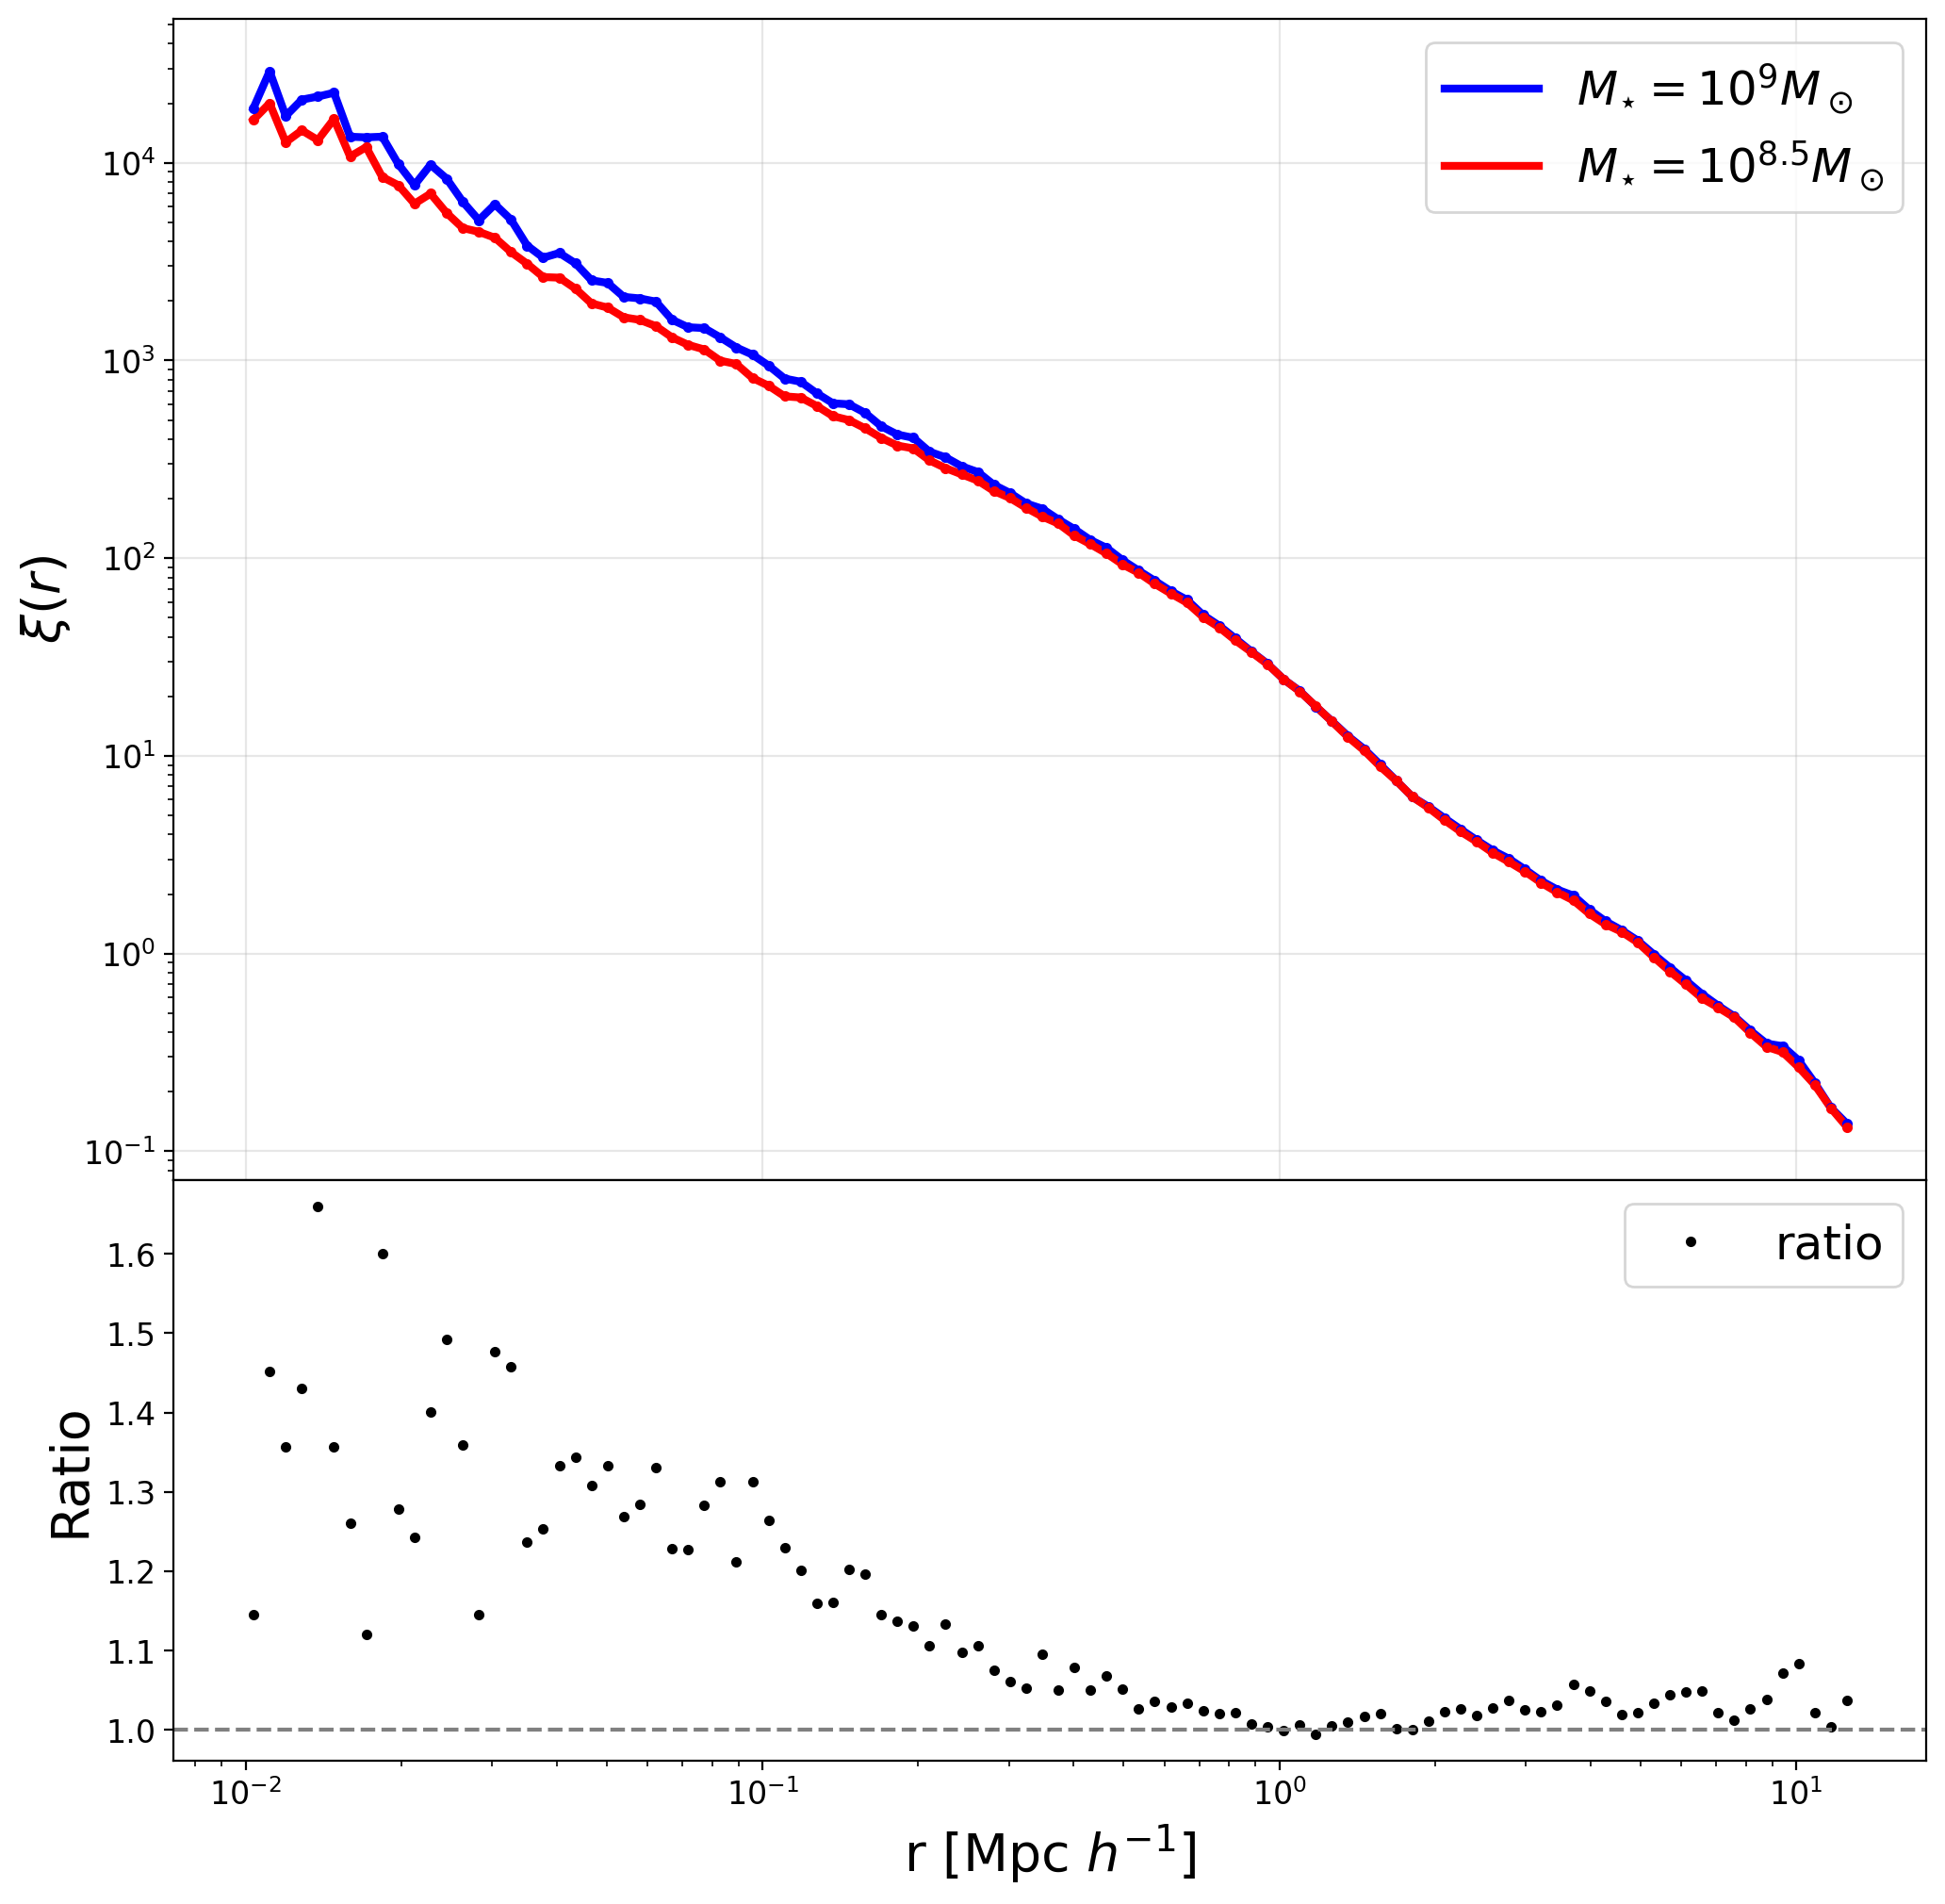

In [42]:

# Create figure with GridSpec
fig = plt.figure(figsize=(12, 12), dpi = 200)
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.0)

#create ratios for lower plot
ratio_N_max = (xires_stars_9_downsampled['xi']/xires_stars_downsampled['xi'])

# Main plot
ax_main = fig.add_subplot(gs[0])
ax_main.plot(rmid/(1000), xires_stars_9_downsampled['xi'], color='blue', lw= 3, label=r'$M_{\star} = 10^9 M_\odot$')
ax_main.plot(rmid/(1000), xires_stars_downsampled["xi"], color='red', label = r'$M_{\star} = 10^{8.5} M_\odot$',lw =3)
ax_main.errorbar(rmid/(1000), xires_stars_9_downsampled["xi"], fmt='o', color='blue', markersize =3)
ax_main.errorbar(rmid/(1000), xires_stars_downsampled["xi"], fmt='o', color='red', markersize = 3)
ax_main.tick_params(axis='both', which='major', labelsize=12)

plt.xscale('log'); plt.yscale('log')
ax_main.set_ylabel(r"$\xi(r)$", fontsize = 20)
plt.grid(alpha=0.3)
plt.legend(fontsize = 18)
ax_main.tick_params(bottom=False)  # remove x-axis ticks for main plot

# Ratio / comparison plot
ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
ax_ratio.plot(rmid/(1000), ratio_N_max, '.', label=r'ratio', color='black')
ax_ratio.axhline(1, color='gray', linestyle='--')
ax_ratio.set_xlabel(r'r [Mpc $h^{-1}$]', fontsize = 20)
ax_ratio.set_ylabel('Ratio', fontsize = 20)
ax_ratio.tick_params(axis='both', which='major', labelsize=12)

# Set desired y-ticks
#ax_ratio.set_yticks([0.7, 0.80, 0.90, 1.00, 1.10,1.2])
#ax_ratio.set_ylim(0.8, 1.2)
ax_ratio.legend(fontsize = 18)

plt.savefig('Images/2PCF.png')
plt.show()

In [43]:
import seaborn as sns


# Parameters
Mtot_min = 1e9                # hard lower cutoff
mass_ratio_thresh = 0.4       # satellite if total_mass / Mcentral < this
fb_thresh = 0.6              # stripped  if baryon fraction > this
min_in_bin = 5                # minimum objects to compute median in a bin
bin_width_dex = 0.5
# ------------------------------------------------

#  Zero mass threshold (also enforce Mtot >= 1e9)
valid = (
    (total_mass > 0)
    & (total_mass_type[:, 1] > Mtot_min)   # dark matter > 0
    & (total_mass_type[:, 4] > 0)   # stars > 0
)

# Extract arrays for valid objects 
Mtot = total_mass[valid]
Mgas = total_mass_type[valid, 0]
Mdm  = total_mass_type[valid, 1]
Mstar = total_mass_type[valid, 4]
parents = subhalo_parents[valid]   # subparent index for valid objects
grnr = subhalo_grnr.astype(np.int64)  # keep full array for group-based ops below

#  simple subparent criterion: centrals 
is_central_subparent = (parents == 0)   

# compute group-central masses using group numbers
grnr_full = subhalo_grnr.astype(np.int64)
if grnr_full.min() == 1:
    grnr_full = grnr_full - 1

N = len(total_mass)
n_groups = grnr_full.max() + 1

# sort by group and by mass to find central per group
sort_idx = np.argsort(grnr_full)
grnr_sorted = grnr_full[sort_idx]
mass_sorted = total_mass[sort_idx]

# group edges and max mass per group
group_edges = np.searchsorted(grnr_sorted, np.arange(n_groups), side='left')
group_edges = np.append(group_edges, N)
max_mass_per_group = np.maximum.reduceat(mass_sorted, group_edges[:-1])

# assign central-group-mass back to each subhalo (unsort)
Mcentral_group = max_mass_per_group[grnr_sorted]
Mcentral_group_unsorted = np.empty_like(Mcentral_group)
Mcentral_group_unsorted[sort_idx] = Mcentral_group
Mcentral_group_full = Mcentral_group_unsorted  # length N, aligned with full arrays

# --- compute group richness (N_group)
group_sizes = np.diff(group_edges)            # number of subhalos in each group 
# map group size back to the full array positions:
group_size_sorted = group_sizes[grnr_sorted]  # length N sorted
group_size_unsorted = np.empty_like(group_size_sorted)
group_size_unsorted[sort_idx] = group_size_sorted
group_size_full = group_size_unsorted       


# --- 3) satellite / stripped classification (on full arrays), then apply valid mask ---
f_mass_full = total_mass / Mcentral_group_full            # mass ratio to group central
fb_full = (total_mass_type[:, 0] + total_mass_type[:, 4]) / total_mass  # baryon fraction

is_central_full = np.zeros(N, dtype=bool)
# find most massive index per group (same as original approach)
central_local = np.full(n_groups, -1, dtype=np.int64)
for g in range(n_groups):
    start, end = group_edges[g], group_edges[g+1]
    if start == end:
        continue
    local_idx = np.argmax(mass_sorted[start:end])
    central_local[g] = start + local_idx
valid_groups = central_local < N
central_indices = sort_idx[central_local[valid_groups]]
is_central_full[central_indices] = True

# Candidates: not central (by group) and mass ratio below threshold
is_sat_candidate_full = (~is_central_full) & (f_mass_full < mass_ratio_thresh)

# Stripped if baryon fraction high (low DM fraction left)
is_stripped_full = (~is_central_full) & (fb_full > fb_thresh)

# Final satellite definition: candidate and not stripped
is_satellite_final_full = is_sat_candidate_full & (~is_stripped_full)

# Apply mask to get centrals/satellites/stripped
valid_idx = np.nonzero(valid)[0]  
is_central_valid_by_group = is_central_full[valid_idx]
is_satellite_valid = is_satellite_final_full[valid_idx]
is_stripped_valid = is_stripped_full[valid_idx]

# now restrict medians to centrals with at least Nmin members
Nmin = 8
group_size_valid = group_size_full[valid_idx]   
is_group_central = is_central_full[valid_idx]   

# Combine with subparent centrals: we keep subparent centrals as centrals regardless of group detection
is_central_final = is_central_subparent | is_central_valid_by_group
# exclude any centrals from the satellite set
is_satellite_final = is_satellite_valid & (~is_central_final)
is_stripped_final = is_stripped_valid & (~is_central_final)

# central candidates to use in medians: centrals and group size >= Nmin OR subparent centrals 
central_for_medians = is_central_final & (group_size_valid >= Nmin)
# alternatively: treat isolated centrals separately
isolated_centrals = is_central_final & (group_size_valid == 1)



# --- 4) build arrays for centrals, satellites, stripped 
Mdm_c = Mdm[central_for_medians]
Mstar_c = Mstar[central_for_medians]
Mgas_c = Mgas[central_for_medians]
Mtot_c = Mtot[central_for_medians]

Mdm_s = Mdm[is_satellite_final]
Mstar_s = Mstar[is_satellite_final]
Mgas_s = Mgas[is_satellite_final]
Mtot_s = Mtot[is_satellite_final]

Mdm_strip = Mdm[is_stripped_final]
Mstar_strip = Mstar[is_stripped_final]
Mgas_strip = Mgas[is_stripped_final]
Mtot_strip = Mtot[is_stripped_final]

#median-with-16/84 function 
def median_with_error(x, y, bin_min=None, bin_max=None, bin_width=bin_width_dex, min_count=min_in_bin):
    if bin_min is None:
        bin_min = np.floor(np.log10(np.nanmin(x)))
    if bin_max is None:
        bin_max = np.ceil(np.log10(np.nanmax(x)))
    edges = 10**np.arange(bin_min, bin_max + 1e-9, bin_width)
    centers = np.sqrt(edges[:-1] * edges[1:])
    med, low, high = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (x > lo) & (x <= hi)
        if np.sum(mask) < min_count:
            med.append(np.nan); low.append(np.nan); high.append(np.nan); continue
        v = y[mask]
        m = np.median(v)
        p16, p84 = np.percentile(v, [16, 84])
        med.append(m); low.append(m - p16); high.append(p84 - m)
    return centers, np.array(med), np.array(low), np.array(high)

# stellar-to-halo ratios
R_c = Mstar_c / Mdm_c
R_s = Mstar_s / Mdm_s

# choose bin range based on centrals 
bin_min = np.floor(np.log10(np.nanmin(Mdm_c))) if len(Mdm_c)>0 else 7
bin_max = np.ceil(np.log10(np.nanmax(Mdm_c))) if len(Mdm_c)>0 else 14

bin_centers, med_c, low_c, high_c = median_with_error(Mdm_c, R_c, bin_min, bin_max)
_, med_s, low_s, high_s = median_with_error(Mdm_s, R_s, bin_min, bin_max)

# baryon fractions
fb_c = (Mstar_c + Mgas_c) / Mtot_c
fb_s = (Mstar_s + Mgas_s) / Mtot_s
_, med_fb_c, low_fb_c, high_fb_c = median_with_error(Mdm_c, fb_c, bin_min, bin_max)
_, med_fb_s, low_fb_s, high_fb_s = median_with_error(Mdm_s, fb_s, bin_min, bin_max)




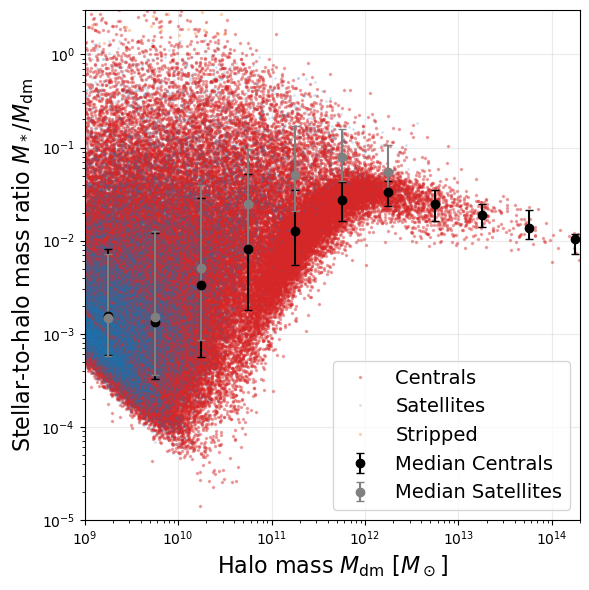

In [44]:
# Plot: Stellar-to-halo mass ratio
plt.figure(figsize=(6,6))
ax = plt.gca()

# raw points
ax.loglog(Mdm_c, R_c, '.', ms=3, alpha=0.35, color='tab:red', label='Centrals ')
ax.loglog(Mdm_s, R_s, '.', ms=2.5, alpha=0.12, color='tab:blue', label='Satellites')
ax.loglog(Mdm_strip, Mstar_strip/Mdm_strip, '.', ms=3, alpha=0.25, color='tab:orange', label='Stripped')

# medians + errorbars (black for centrals, grey for satellites)
ax.errorbar(bin_centers, med_c, yerr=[low_c, high_c],
            fmt='o', color='black', ms=6, capsize=3, label='Median Centrals')
ax.errorbar(bin_centers, med_s, yerr=[low_s, high_s],
            fmt='o', color='grey', ms=6, capsize=3, label='Median Satellites')

ax.set_xlim(1e9, 2e14)
ax.set_ylim(1e-5, 3)
ax.set_xlabel(r"Halo mass $M_{\rm dm}$ [$M_\odot$]", fontsize = 16)
ax.set_ylabel(r"Stellar-to-halo mass ratio $M_*/M_{\rm dm}$", fontsize = 16)
ax.grid(alpha=0.25)
ax.legend(frameon=True, loc='lower right', fontsize = 14)
plt.tight_layout()
plt.savefig("Images/SHMR_improved.png", dpi=300)
plt.show()



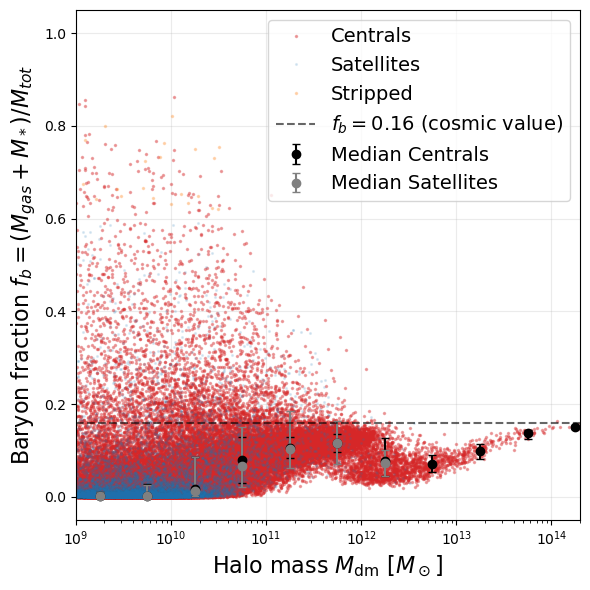

In [45]:
# Plot: Baryon fraction vs halo mass 
plt.figure(figsize=(6,6))
ax = plt.gca()
ax.semilogx(Mdm_c, fb_c, '.', ms=3, alpha=0.35, color='tab:red', label='Centrals')
ax.semilogx(Mdm_s, fb_s, '.', ms=2.5, alpha=0.12, color='tab:blue', label='Satellites')
ax.semilogx(Mdm_strip, (Mstar_strip+Mgas_strip)/Mtot_strip, '.', ms=3, alpha=0.25, color='tab:orange', label='Stripped')

ax.errorbar(bin_centers, med_fb_c, yerr=[low_fb_c, high_fb_c],
            fmt='o', color='black', ms=6, capsize=3, label='Median Centrals')
ax.errorbar(bin_centers, med_fb_s, yerr=[low_fb_s, high_fb_s],
            fmt='o', color='grey', ms=6, capsize=3, label='Median Satellites')

ax.axhline(y=0.16, color='k', ls='--', alpha=0.6, label=r"$f_b = 0.16$ (cosmic value)")

ax.set_xlim(1e9, 2e14)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel(r"Halo mass $M_{\rm dm}$ [$M_\odot$]", fontsize = 16)
ax.set_ylabel(r"Baryon fraction $f_b = (M_{gas}+M_*)/M_{tot}$", fontsize = 16)
ax.grid(alpha=0.25)
ax.legend(frameon=True, loc='upper right', fontsize = 14)
plt.tight_layout()
plt.savefig("Images/BaryonFraction_improved.png", dpi=300)
plt.show()

Best-fit parameters:
N = 2.9414e-02 +/- 1.7599e-04
M1 = 2.129e+11 Msun +/- 4.862e-14
beta = 1.049 +/- 0.040
gamma = 0.296 +/- 0.001


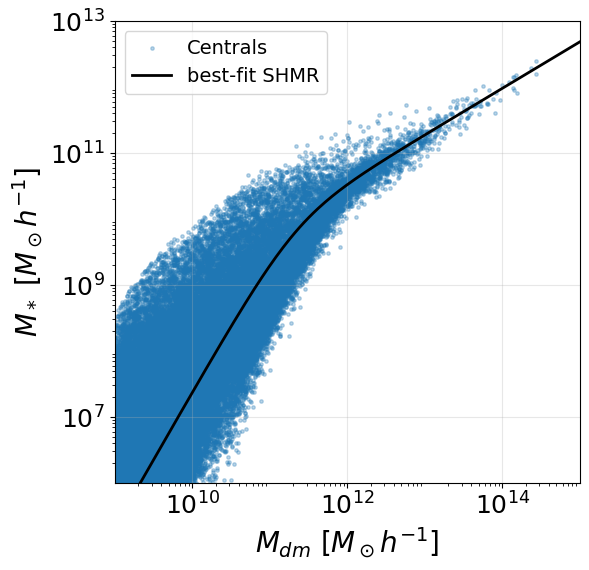

In [46]:
# ----- Define the SHMR function -----
def shmr(Mdm, N, M1, beta, gamma):
    # M200 and M1 in same units (Msun)
    x = Mdm / M1
    return 2.0 * N * Mdm / (x**(-beta) + x**(gamma))

"""
# If you prefer to fit log10(y), wrap the function:
def shmr_log10(M200, N, M1, beta, gamma):
    vals = shmr(M200, N, M1, beta, gamma)
    return np.log10(vals)
"""

# ----- Fit in log space (recommended) -----
xdata = Mtot_c*h
ydata = Mstar_c*h

# initial guesses
p0 = [0.02, 1e12, 1.0, 0.5]  # [N, M1(Msun), beta, gamma]
# bounds to keep physical values (example)
lower = [0, 10**10.5, 0.0, 0.0]
upper = [2.0, 10**12.5, 5.0, 5.0]

# Use curve_fit; fit log10 of the model to ydata
popt, pcov = curve_fit(lambda M, N, M1, beta, gamma: shmr(M, N, M1, beta, gamma),
                       xdata, ydata, p0=p0, bounds=(lower, upper), maxfev=20000)

N_fit, M1_fit, beta_fit, gamma_fit = popt
perr = np.sqrt(np.diag(pcov))

print("Best-fit parameters:")
print("N = {:.4e} +/- {:.4e}".format(N_fit, perr[0]))
print("M1 = {:.3e} Msun +/- {:.3e}".format(M1_fit, perr[1]))
print("beta = {:.3f} +/- {:.3f}".format(beta_fit, perr[2]))
print("gamma = {:.3f} +/- {:.3f}".format(gamma_fit, perr[3]))

# ----- Make a plot -----
Mdm_grid = np.logspace(9, 15, 200)
model_ratio = shmr(Mdm_grid, *popt)

plt.figure(figsize=(6,6))
plt.scatter(xdata, ydata, s=6, alpha=0.3, label='Centrals')
plt.plot(Mdm_grid, model_ratio, lw=2, color='black', label='best-fit SHMR')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'$M_{dm}\ [M_\odot h^{-1}]$', fontsize = 20)
plt.ylabel(r'$M_*\ [M_\odot h^{-1}]$', fontsize = 20)
plt.ylim(10**6,10**13)
plt.xlim(10**9,10**15)
plt.xticks([1e10, 1e12, 1e14], [r'$10^{10}$', r'$10^{12}$', r'$10^{14}$'])
plt.yticks([1e7, 1e9, 1e11, 1e13], [r'$10^{7}$', r'$10^{9}$', r'$10^{11}$', r'$10^{13}$'])
plt.tick_params(axis='both', which='major', labelsize=18)  # adjust 14 to desired size
plt.legend(fontsize = 14)
plt.grid(alpha=0.3)
plt.savefig("Images/SHMR_fit")
plt.show()

C:\Users\grego\AppData\Local\Temp\ipykernel_17008\1759603642.py:42: RuntimeWarning: divide by zero encountered in log10
  log_med_c = np.log10(med_SFR_central)

C:\Users\grego\AppData\Local\Temp\ipykernel_17008\1759603642.py:43: RuntimeWarning: divide by zero encountered in log10
  log_med_s = np.log10(med_SFR_sat)

C:\Users\grego\AppData\Local\Temp\ipykernel_17008\1759603642.py:46: RuntimeWarning: divide by zero encountered in log10
  log_err_low_c  = log_med_c - np.log10(med_SFR_central - sigma_low_SFR_central)

C:\Users\grego\AppData\Local\Temp\ipykernel_17008\1759603642.py:46: RuntimeWarning: invalid value encountered in subtract
  log_err_low_c  = log_med_c - np.log10(med_SFR_central - sigma_low_SFR_central)

C:\Users\grego\AppData\Local\Temp\ipykernel_17008\1759603642.py:47: RuntimeWarning: divide by zero encountered in log10
  log_err_high_c = np.log10(med_SFR_central + sigma_high_SFR_central) - log_med_c

C:\Users\grego\AppData\Local\Temp\ipykernel_17008\1759603642.py:47: Runti

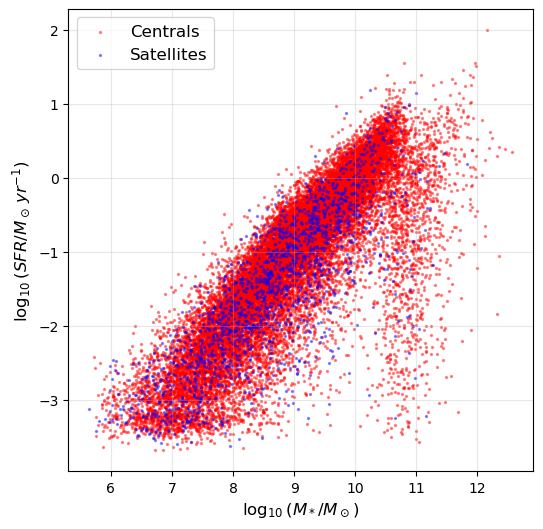

In [47]:
# redefine needed masks
mask_suitable = np.asarray(data['Subhalo']['SubhaloFlag'], dtype=np.uint8)  # suitable halos

# SFR array
SFR_haloes = np.asarray(data['Subhalo']["SubhaloSFR"])

# Apply masks consistently
SFR_haloes_valid = SFR_haloes[mask_suitable == 1][valid]

SFR_haloes_central = SFR_haloes_valid[central_for_medians]
SFR_haloes_satellites = SFR_haloes_valid[is_satellite_final]

# define bins (based on centrals, as before)
bin_width_dex_SFR = 0.5
logM_min_SFR = np.floor(np.log10(Mstar_c.min()))
logM_max_SFR = np.ceil(np.log10(Mstar_c.max()))
bin_edges_SFR = 10**np.arange(logM_min_SFR, logM_max_SFR + 1e-9, bin_width_dex_SFR)
bin_central_SFR = np.sqrt(bin_edges_SFR[:-1] * bin_edges_SFR[1:])

# median SFRs
bin_centers_SFR, med_SFR_central, sigma_low_SFR_central, sigma_high_SFR_central = \
    median_with_error(Mstar_c, SFR_haloes_central,
                      bin_min=logM_min_SFR, bin_max=logM_max_SFR,
                      bin_width=bin_width_dex_SFR)

_, med_SFR_sat, sigma_low_SFR_sat, sigma_high_SFR_sat = \
    median_with_error(Mstar_s, SFR_haloes_satellites,
                      bin_min=logM_min_SFR, bin_max=logM_max_SFR,
                      bin_width=bin_width_dex_SFR)

# Remove zeros/negatives before log
valid_c = (Mstar_c > 0) & (SFR_haloes_central > 0)
valid_s = (Mstar_s > 0) & (SFR_haloes_satellites > 0)

logMstar_c = np.log10(Mstar_c[valid_c])
logSFR_c   = np.log10(SFR_haloes_central[valid_c])

logMstar_s = np.log10(Mstar_s[valid_s])
logSFR_s   = np.log10(SFR_haloes_satellites[valid_s])

log_bin_centers = np.log10(bin_centers_SFR)
log_med_c = np.log10(med_SFR_central)
log_med_s = np.log10(med_SFR_sat)

# Proper log error propagation (asymmetric)
log_err_low_c  = log_med_c - np.log10(med_SFR_central - sigma_low_SFR_central)
log_err_high_c = np.log10(med_SFR_central + sigma_high_SFR_central) - log_med_c

log_err_low_s  = log_med_s - np.log10(med_SFR_sat - sigma_low_SFR_sat)
log_err_high_s = np.log10(med_SFR_sat + sigma_high_SFR_sat) - log_med_s

# Plot
plt.figure(figsize=(6,6))

plt.scatter(logMstar_c, logSFR_c, s=2, alpha=0.4, color='red', label='Centrals')
plt.scatter(logMstar_s, logSFR_s, s=2, alpha=0.4, color='blue', label='Satellites')

"""
plt.errorbar(log_bin_centers,
             log_med_c,
             yerr=[log_err_low_c, log_err_high_c],
             fmt='o', color='black', capsize=3, label='Median Centrals')

plt.errorbar(log_bin_centers,
             log_med_s,
             yerr=[log_err_low_s, log_err_high_s],
             fmt='o', color='grey', capsize=3, label='Median Satellites')
"""

plt.xlabel(r"$\log_{10}(M_*/M_\odot)$", fontsize=12)
plt.ylabel(r"$\log_{10}(SFR / M_\odot\,yr^{-1})$", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()


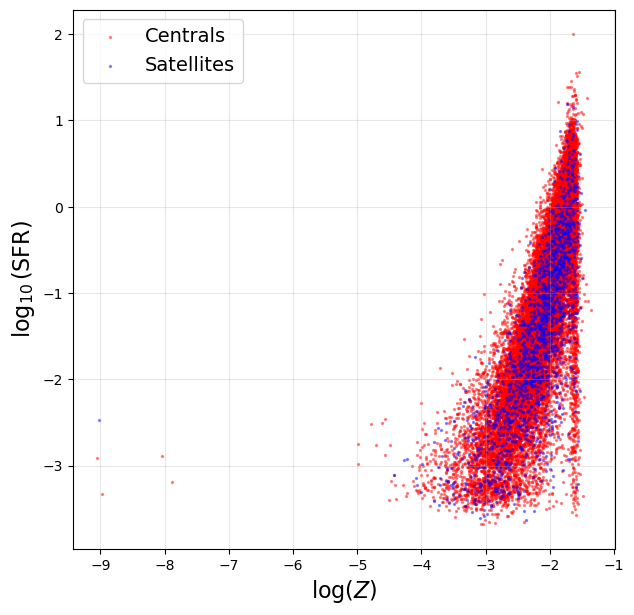

In [48]:
# metallicity and metal fraction
Z_gas = np.asarray(data['Subhalo']["SubhaloGasMetallicity"])
metal_fraction_gas = np.asarray(data['Subhalo']["SubhaloGasMetalFractions"])  # H, He, C, N, O, Ne, Mg, Si, Fe, total_other
Z_stars = np.asarray(data['Subhalo']["SubhaloStarMetallicity"])
metal_fraction_stars = np.asarray(data['Subhalo']["SubhaloStarMetalFractions"])

# apply masks consistently
Z_stars_valid = Z_stars[mask_suitable == 1][valid]

Z_stars_central = Z_stars_valid[central_for_medians]
Z_stars_satellites = Z_stars_valid[is_satellite_final]

# define bins
bin_width_dex_Z = 0.5
logM_min_Z = np.floor(np.log10(Mstar_c.min()))
logM_max_Z = np.ceil(np.log10(Mstar_c.max()))
bin_edges_Z = 10**np.arange(logM_min_Z, logM_max_Z + 1e-9, bin_width_dex_Z)
bin_central_Z = np.sqrt(bin_edges_Z[:-1] * bin_edges_Z[1:])

#central filters
valid_c_ZSFR = (
    (Mstar_c > 0) &
    (Z_stars_central > 0) &
    (SFR_haloes_central > 0)
)

logZ_c   = np.log10(Z_stars_central[valid_c_ZSFR])
logSFR_c = np.log10(SFR_haloes_central[valid_c_ZSFR])

#central satellites
valid_s_ZSFR = (
    (Mstar_s > 0) &
    (Z_stars_satellites > 0) &
    (SFR_haloes_satellites > 0)
)

logZ_s   = np.log10(Z_stars_satellites[valid_s_ZSFR])
logSFR_s = np.log10(SFR_haloes_satellites[valid_s_ZSFR])


# Plot Z–SFR
plt.figure(figsize=(7,7))

plt.scatter(logZ_c, logSFR_c, s=2, alpha=0.4, color='red', label='Centrals')
plt.scatter(logZ_s, logSFR_s, s=2, alpha=0.4, color='blue', label='Satellites')


plt.xlabel(r"$\log(Z)$", fontsize=16)
plt.ylabel(r"$\log_{10}(\mathrm{SFR})$", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(fontsize=14)
plt.savefig("Images/Z-SFR")
plt.show()


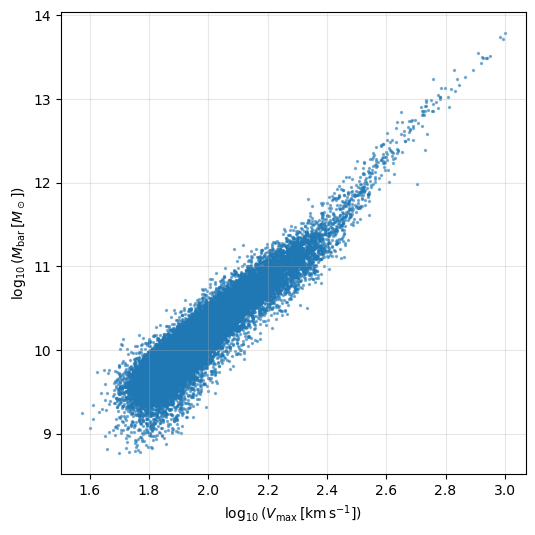

In [49]:
valid = (
    (total_mass > 0)
    & (total_mass_type[:, 1] > Mtot_min)
    & (total_mass_type[:, 4] > 0)
)


mask_suitable = np.asarray(data['Subhalo']['SubhaloFlag'], dtype=np.uint8) == 1

Vmax_full = np.asarray(data['Subhalo']['SubhaloVmax'])[mask_suitable]
SFR_full  = np.asarray(data['Subhalo']['SubhaloSFR'])[mask_suitable]


# Restrict to the same subhalo catalogue as total_mass_type
Vmax = Vmax_full[valid]
SFR  = SFR_full[valid]

Mstar = total_mass_type[valid, 4]
Mgas  = total_mass_type[valid, 0]
Mbar  = Mstar + Mgas

is_central_valid = is_central_full[valid]

# --- Base physical validity
mask_phys = (Mbar > 0) & (Vmax > 0)

Vmax = Vmax[mask_phys]
Mbar = Mbar[mask_phys]
SFR  = SFR[mask_phys]
is_central_phys = is_central_valid[mask_phys]

# --- Select centrals
mask_central = is_central_phys
Vmax_central = Vmax[mask_central]
Mbar_central = Mbar[mask_central]
SFR_central  = SFR[mask_central]

# --- Optional SFR cut (star-forming centrals)
mask_SFR = SFR_central > 0.01
Vmax_central = Vmax_central[mask_SFR]
Mbar_central = Mbar_central[mask_SFR]

# --- Plot baryonic Tully–Fisher relation
plt.figure(figsize=(6,6))
plt.scatter(np.log10(Vmax_central),
            np.log10(Mbar_central),
            s=2, alpha=0.5)

plt.xlabel(r'$\log_{10}(V_{\rm max}\,[\mathrm{km\,s^{-1}}])$')
plt.ylabel(r'$\log_{10}(M_{\rm bar}\,[M_\odot])$')
plt.grid(alpha=0.3)
plt.savefig("Images/TF-relation")
plt.show()


slope = 3.0835 ± 0.0072
intercept = 4.0669 ± 0.0142


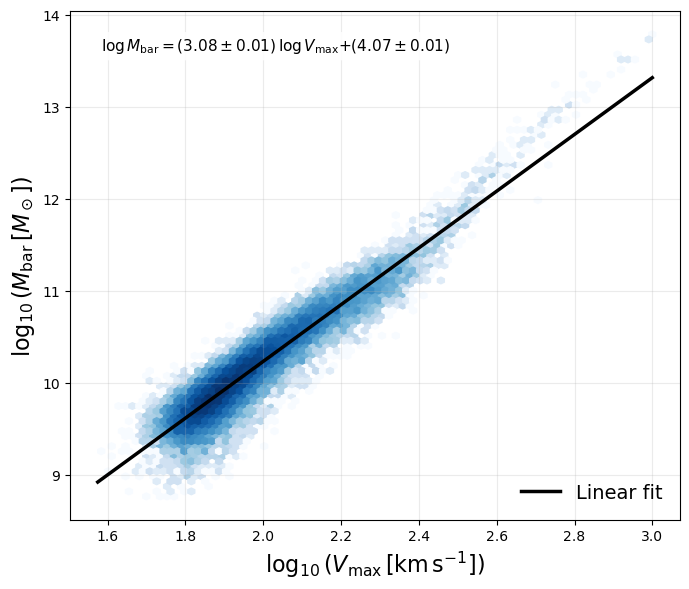

In [50]:
# --- Fit (unchanged)
coeff, cov = np.polyfit(np.log10(Vmax_central),
                        np.log10(Mbar_central),
                        deg=1, cov=True)

slope, intercept = coeff
slope_err, intercept_err = np.sqrt(np.diag(cov))

print(f"slope = {slope:.4f} ± {slope_err:.4f}")
print(f"intercept = {intercept:.4f} ± {intercept_err:.4f}")

x = np.linspace(np.min(np.log10(Vmax_central)),
                np.max(np.log10(Vmax_central)), 200)
y = slope * x + intercept

# --- Plot
plt.figure(figsize=(7,6))

plt.hexbin(np.log10(Vmax_central),
           np.log10(Mbar_central),
           gridsize=80,
           bins='log',
           cmap='Blues')


plt.plot(x, y,
         color="black",
         lw=2.5,
         label="Linear fit")

# Annotation box
text = (
    rf"$\log M_{{\rm bar}} = ({slope:.2f} \pm {slope_err:.2f})\,\log V_{{\rm max}}$"
    rf"$+ ({intercept:.2f} \pm {intercept_err:.2f})$"
)

plt.text(0.05, 0.95, text,
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="none"))

# Labels
plt.xlabel(r'$\log_{10}(V_{\rm max}\,[\mathrm{km\,s^{-1}}])$', fontsize=16)
plt.ylabel(r'$\log_{10}(M_{\rm bar}\,[M_\odot])$', fontsize=16)

# Cosmetics
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=14, loc= 'lower right')
plt.tight_layout()

plt.savefig("Images/TF-relation-fit", dpi=300)
plt.show()
